# T2 — completamento di turno in napoletano | QLoRA su Kaggle T4

Notebook autonomo: **non dipende** da `common.py`, dagli stadi A/A2, dal CSV
parallelo o dagli altri due notebook. Servono tre file — `train.json`,
`dev.json`, `test.json` — e una GPU T4.

## Il compito, detto con precisione

Ogni item e' un turno di conversazione napoletana tagliato **esattamente a
meta' delle parole**. Il modello riceve i tre turni precedenti piu' la prima
meta', e deve produrre la seconda:

```
Conversazione finora:
A: emh
---
Continua il turno di B in napoletano: tu nun l'he' maje fatte sti
                                      └──────── prefisso ────────┘
target:                               ffoto quanno si' ghiuta 'ncopp'a varca
```

Da qui discendono due criteri di successo che **non coincidono** e che il
notebook misura separatamente:

| criterio | domanda | come si misura |
|---|---|---|
| **fedelta'** | sa produrre *quella* continuazione? | `ppl_target`, `acc_token`, chrF++ |
| **plausibilita'** | produce *una* continuazione napoletana e coerente? | densita' dialettale, `ctx_acc`, lettura qualitativa |

Il riferimento e' **uno fra molte continuazioni valide**: un modello che scrive
un napoletano perfetto e pertinente puo' avere un chrF++ basso. Per questo
sotto trovi il fondo scala, e per questo il chrF++ da solo non decide niente.

## Cosa cambia rispetto al notebook precedente

| | prima | adesso |
|---|---|---|
| catena | base -> A (CPT) -> A2 (lessico) -> B (T2) | **un solo stadio** sul modello di base (l'aggancio a un adapter esistente resta, via `INIT_ADAPTER`) |
| formato del prompt | istruzione -> risposta: il modello deve *saldare* la sua risposta al testo dell'utente | **prefill**: il prefisso sta dentro il messaggio dell'assistente, il modello prosegue letteralmente il proprio testo |
| lunghezza in generazione | libera | **budget derivato dal prefisso** (il taglio e' a meta' esatta: la lunghezza attesa e' nota) |
| metriche | chrF++ | chrF++ **piu'** `ppl_target`, `acc_token`, `ctx_acc`, densita' dialettale, tasso di copia, rapporto di lunghezza |
| baseline | assenti nel notebook di training | zero-shot e few-shot **prima** del training, nella stessa sessione |
| dipendenze | `common.py` (48 KB) + 6 moduli | 4 file, ~900 righe in tutto |

Il pezzo che conta di piu' e' il **prefill**. In forma istruzione -> risposta un
modello instruct e' post-addestrato a *cominciare* una risposta: davanti a
`Turno da completare: tu nun l'he' maje fatte sti` la cosa naturale per lui e'
aprire una frase nuova, non incastrarsi in una a meta'. Mettendo il prefisso
dentro il turno dell'assistente, la continuazione e' l'unica cosa che puo'
fare, e la loss cade solo sui token della seconda meta'.

## Ordine di esecuzione

1. Passi 1-3: ambiente, dati, moduli (secondi)
2. Passo 4: **audit dei dati** — leggilo, e' dove si scoprono i problemi che
   rendono inutili i numeri finali
3. Passo 5-6: configurazione e smoke test su modello piccolo (~3 minuti)
4. Passo 7: **baseline zero-shot e few-shot** — servono *prima*, altrimenti a
   fine training non sai da cosa sei partito (~15 minuti)
5. Passo 8: training (~20-40 minuti su T4)
6. Passi 9-11: valutazione su dev, poi su test, tabella finale (~20 minuti)
7. Passo 12: backup su Hugging Face Hub — **non saltarlo**, `/kaggle/working`
   sparisce quando la sessione muore

---

## Cosa cambia in questa versione (v2)

Cinque modifiche, in ordine di impatto atteso. Ognuna e' isolabile: si puo'
spegnerla e rifare il run per misurarne il contributo.

**1. Split ricostruiti dal CSV** (`rebuild_t2_data.py`, Passo 2b). Nei file
originali il taglio del turno e' fisso a meta' delle parole e i turni sotto le
6 parole sono esclusi: 683 istanze di train, il 62% del corpus buttato, e un
EOS che il modello impara come conteggio di parole invece che come fine di
turno. Qui il taglio e' mobile (piu' istanze per turno), la soglia scende a 4
parole e lo split e' a blocchi interlacciati con zona cuscinetto invece che
cronologico a tre segmenti. Effetto misurato sul CSV:

| | train | token di target OOV (dev / test) |
|---|---|---|
| originale (cronologico, taglio fisso) | 683 | 20,6% / 21,7% |
| ricostruito (blocchi, 4 tagli) | ~3.400 | 13,9% / 12,7% |

La deriva tematica era il problema principale: dev e test cadevano
nell'ultimo terzo delle conversazioni, cioe' su argomenti mai visti. Da li'
venivano i frammenti memorizzati (`'a nuvantanove` compare 4 volte nel train,
su un item di dev che parla di cioccolato).

**2. Accuratezza di scelta** (`metrica_scelta.py`, calcolata a ogni
valutazione). Il chrF++ ha una forbice di 2,8 punti fra il caso puro (9,1) e la
baseline banale (11,9): dentro quel margine non distingue un modello che ha
imparato da uno che non ha imparato. La nuova metrica chiede invece se, fra la
continuazione vera e 9 prese da altri turni, il modello sceglie quella giusta.
Fondo scala esatto 0,10, zero generazioni.

**3. Iperparametri per il regime "pochi dati"**. Prima: `lr=1e-4, r=16,
3 epoche`, con il best checkpoint a fine prima epoca (overfitting immediato).
Ora `lr=2e-5, r=8, dropout=0.1, weight_decay=0.01, NEFTune=5, 6 epoche`.

**4. Ricerca contrastiva al posto della greedy**. `penalty_alpha=0.6,
top_k=4`: penalizza i token la cui rappresentazione e' troppo simile a quelle
gia' emesse, che e' esattamente il meccanismo dei cicli. In piu'
`min_new_tokens` deriva dalla lunghezza attesa invece di essere fisso a 2 (il
rapporto di lunghezza era sceso a 0,64).

**5. Loss anche sul prefisso, a peso 0,3**. Con la maschera piena la
supervisione e' di ~12 token per esempio. Sbloccando il prefisso del turno
(mai l'impalcatura: system, contesto e istruzione restano a -100) raddoppia, e
il modello impara la struttura interna del turno invece della sola seconda
meta'. `--peso-prefisso 0` riproduce il comportamento precedente.

Restano invariati il `prefill`, `ctx_acc` e tutte le baseline di taratura.

---

## Passaggio a Llama-2-7b-chat

Il codice è indipendente dal modello: `MODEL_REGISTRY` conteneva
`meta-llama/Llama-2-7b-chat-hf` fin dall'inizio, e `scegli_dtype`, `attn_impl`,
`extra_forward` e `moduli_lora` si tarano sulla firma e sull'architettura che
trovano, non sul nome. Il confronto fra i tre:

| | Minerva-7B | Gemma-3-4b | **Llama-2-7b-chat** |
|---|---|---|---|
| precisione su T4 | fp16 | fp32 | **fp16** |
| durata (3 epoche) | ~2h15 | 4-5 h | **~2h15** |
| batch / accumulo | 2 x 8 | 1 x 16 | **2 x 8** |
| vocabolario | ~51k | 262k | **32k** |
| attenzione | sdpa | eager | **sdpa** |
| `token_type_ids` | no | sì | **no** |
| fine turno | token dedicato | `<end_of_turn>` | **`</s>` (l'EOS)** |
| smoke test | SmolLM2-135M | `gemma-3-1b-it` | **TinyLlama-1.1B** |

Due cose da sapere prima di lanciare. Llama-2 è **gated**: il token della cella
3d è obbligatorio e la licenza va accettata su `meta-llama/Llama-2-7b-chat-hf`
con lo stesso account. E il tokenizer è **SentencePiece**, quindi tieni
d'occhio `prefix_mismatch` nell'output del training: `DatasetT2` misura il
prefisso comune reale e maschera correttamente, ma un valore alto ti dice che il
confine prompt/target non cade dove credi.

E una da sapere leggendo i risultati: Llama-2 non conosce il napoletano. Se
`densita_dial_gen` resta molto sotto lo 0,26-0,28 dei riferimenti, non è un
difetto del setup — è il dato.


## Passo 1 — ambiente e GPU

Verifica che ci sia una GPU e **quale**. La T4 e' compute capability 7.5: bf16 non esiste in hardware. `torch.cuda.is_bf16_supported()` risponde comunque `True` perche' conta anche l'emulazione via software: e' il modo classico di rendere il training molto piu' lento senza accorgersene. Qui si guarda la capability, non quella funzione.

In [1]:
# --- 1. Ambiente -------------------------------------------------------------
!pip install -q -U peft bitsandbytes accelerate sacrebleu

import importlib, torch
for m in ("torch", "transformers", "peft", "bitsandbytes", "accelerate", "sacrebleu"):
    try:
        print(f"{m:14s}", importlib.import_module(m).__version__)
    except Exception as e:
        print(f"{m:14s} NON DISPONIBILE ({e})")

if not torch.cuda.is_available():
    raise SystemExit("Nessuna GPU. Settings > Accelerator > GPU T4 x2.")
cc = torch.cuda.get_device_capability(0)
gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nGPU: {torch.cuda.get_device_name(0)} (cc {cc[0]}.{cc[1]}) | {gb:.1f} GB")
print("precisione che verra' usata:", "bf16" if cc[0] >= 8 else "fp16",
      "  (bf16 richiede cc >= 8)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 10.0 MB/s eta 0:00:00
torch          2.10.0+cu128
transformers   5.0.0
peft           0.20.0
bitsandbytes   0.50.2
accelerate     1.14.0
sacrebleu      2.6.0

GPU: Tesla T4 (cc 7.5) | 15.6 GB
precisione che verra' usata: fp16   (bf16 richiede cc >= 8)


In [2]:
# --- 2. Cartella di lavoro ---------------------------------------------------
import os, sys, pathlib
pathlib.Path("/kaggle/working/training").mkdir(parents=True, exist_ok=True)
os.chdir("/kaggle/working/training")
sys.path.insert(0, "/kaggle/working/training")   # perche' `import t2_common` funzioni
os.environ["CUDA_VISIBLE_DEVICES"] = "0"         # una GPU sola anche su T4 x2:
                                                 # con device_map={"":0} la seconda
                                                 # resterebbe ferma comunque
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("cwd:", os.getcwd())

cwd: /kaggle/working/training


## Passo 2 — i dati

**Attenzione qui: e' il punto dove si sbaglia.** Se il Dataset che hai allegato
contiene tutti e tre i layout, `/kaggle/input` ha tre cartelle con dentro tre
file `train.json` identici di nome e diversissimi di contenuto. Prendere il
primo in ordine alfabetico significa addestrare T2 sui dati di T1 (traduzione):
il notebook parte, l'audit segnala il problema, e poi tutto crolla con
`item senza istruzione attesa`.

La cella qui sotto sceglie sul **contenuto**: elenca tutti i candidati, tiene
solo quelli i cui prompt contengono `Continua il turno in napoletano:`, e alla
fine verifica che la marca ci sia in **tutti** gli item — con un `assert`, non
con un `print`. Se la scelta automatica sbaglia comunque, riempi `SPLIT_SRC`
con il percorso della cartella `layout2_completamento_turno`.

I file vengono copiati in `/kaggle/working/split` perche' `/kaggle/input` e' in
sola lettura.

In [3]:
# --- 3. Trova lo split GIUSTO e rendilo scrivibile ---------------------------
# Se il Dataset contiene tutti e tre i layout, qui va scelto il layout2. La
# scelta si fa sul CONTENUTO dei file, non sul nome della cartella: e' l'unico
# controllo che non si puo' aggirare per distrazione.
import glob, json, os, shutil, sys
sys.path.insert(0, "/kaggle/working/training")

SPLIT_SRC = ""      # <-- riempi SOLO se la ricerca automatica sbaglia

MARCA = "Continua il turno in napoletano:"

def candidati(radice="/kaggle/input"):
    out = []
    for p in sorted(glob.glob(f"{radice}/**/train.json", recursive=True)):
        d = os.path.dirname(p)
        if not all(os.path.exists(f"{d}/{s}.json") for s in ("dev", "test")):
            continue
        try:
            r = json.load(open(p, encoding="utf-8"))
        except Exception:
            continue
        if not r:
            continue
        e_t2 = MARCA in r[0].get("prompt", "") and r[0].get("layout") in ("T2", None)
        out.append((d, e_t2, r[0].get("layout"), len(r)))
    return out

cand = candidati()
print("cartelle con train/dev/test.json trovate:")
for d, ok, lay, n in cand:
    print(f"  [{'T2 OK' if ok else '  no '}] layout={str(lay):4s} n={n:5d}  {d}")

# Questa cella NON e' piu' bloccante: il Passo 2b puo' ricostruire gli split
# dal solo CSV. Se qui non si trova niente, si va avanti con SPLIT vuoto e
# SCHEMA="v2" nella cella 3c.
buoni = [d for d, ok, _, _ in cand if ok]
SPLIT_RO = SPLIT_SRC or (buoni[0] if buoni else "")
if not SPLIT_RO:
    print("\n! nessuna cartella con il layout2. Va bene: il Passo 2b "
          "ricostruisce gli split dal CSV.\n  Lascia SCHEMA='v2' nella cella 3c.")
    SPLIT = ""
elif len(buoni) > 1 and not SPLIT_SRC:
    print("\n! piu' candidati validi, prendo il primo. Se non e' quello "
          "giusto, imposta SPLIT_SRC a mano.")

if SPLIT_RO:
  SPLIT = "/kaggle/working/split"
  shutil.rmtree(SPLIT, ignore_errors=True)
  os.makedirs(SPLIT, exist_ok=True)
  for s in ("train", "dev", "test"):
      shutil.copy(f"{SPLIT_RO}/{s}.json", f"{SPLIT}/{s}.json")

  print("\nsorgente :", SPLIT_RO)
  print("SPLIT    :", SPLIT)
  for s in ("train", "dev", "test"):
      d = json.load(open(f"{SPLIT}/{s}.json", encoding="utf-8"))
      marca = sum(1 for r in d if MARCA in r["prompt"])
      ctx = sum(1 for r in d if "Conversazione finora" in r["prompt"])
      print(f"  {s:5s} {len(d):4d} istanze | layout={d[0].get('layout')} | "
            f"{marca} con la marca T2 | {ctx} con contesto")
      assert marca == len(d), (
          f"{s}.json non e' il layout2: solo {marca}/{len(d)} prompt hanno la "
          f"marca '{MARCA}'. Correggi SPLIT_SRC prima di andare avanti.")
  print("\nOK: e' il layout2 (completamento di turno).")


cartelle con train/dev/test.json trovate:
  [  no ] layout=T1   n= 1134  /kaggle/input/datasets/lucagiuliano/split-dati/split/split/layout1_traduzione_con_contesto
  [T2 OK] layout=T2   n=  683  /kaggle/input/datasets/lucagiuliano/split-dati/split/split/layout2_completamento_turno
  [  no ] layout=T3   n=  748  /kaggle/input/datasets/lucagiuliano/split-dati/split/split/layout3_replica_conversazionale

sorgente : /kaggle/input/datasets/lucagiuliano/split-dati/split/split/layout2_completamento_turno
SPLIT    : /kaggle/working/split
  train  683 istanze | layout=T2 | 683 con la marca T2 | 682 con contesto
  dev    142 istanze | layout=T2 | 142 con la marca T2 | 141 con contesto
  test   147 istanze | layout=T2 | 147 con la marca T2 | 145 con contesto

OK: e' il layout2 (completamento di turno).


## Passo 2b — ricostruzione degli split dal CSV

Il Passo 2 trova i JSON gia' pronti. Questo passo li **rifa' dal CSV
parallelo**, ed e' la modifica con il rapporto valore/costo piu' alto di tutto
il notebook: costa dieci secondi di CPU e cambia i dati su cui gira tutto il
resto.

Tre cose che cambiano rispetto ai file originali.

**Il taglio del turno diventa mobile.** Prima il prefisso era la meta' esatta
delle parole, sempre. Il risultato e' che l'EOS che il modello impara non e'
una fine di turno linguistica ma un conteggio di parole: gli si insegna
"fermati dopo k parole", non "completa il turno". Con piu' punti di taglio per
turno lo stesso testo produce piu' istanze e il segnale "dove finisce un
turno" smette di essere un artefatto.

**La soglia scende da 6 a 4 parole.** Con la soglia a 6, 1.588 turni su 2.568
(il 62% del corpus) non diventavano mai un item. Restavano disponibili come
contesto, ma non come bersaglio.

**Lo split diventa a blocchi interlacciati.** Questo e' il punto che spiega i
frammenti fuori tema nelle generazioni. Lo split cronologico mette dev e test
nell'ultimo terzo di ogni conversazione, cioe' su argomenti che nel train non
compaiono mai: il 20% dei token di target di dev/test non si e' mai visto in
addestramento. Il modello, con 683 esempi, non puo' fare altro che memorizzare
e poi rigurgitare — `'a nuvantanove` compare quattro volte nel train, su un
item di dev che parla di cioccolato.

I blocchi interlacciati distribuiscono train/dev/test su tutta la
conversazione. Il rischio ovvio e' la fuga di informazione attraverso la
finestra di contesto, ed e' per questo che c'e' una **zona cuscinetto**: un
turno diventa bersaglio solo se i 3 turni che lo precedono (cioe' tutto il suo
contesto) appartengono al suo stesso split. I turni scartati restano
disponibili *come* contesto — sparisce il bersaglio, non il testo.

| | train | token di target OOV (dev / test) |
|---|---|---|
| cronologico, taglio fisso | 683 | 20,6% / 21,7% |
| blocchi, 4 tagli, soglia 4 | ~3.400 | 13,9% / 12,7% |

Con `--split cronologico --tagli 1 --min-turno 6` lo script riproduce
esattamente i file originali (683 / 135 / 141). **Tieni entrambi gli split e
riporta i due risultati**: la differenza fra i due *e'* la misura di quanto la
deriva tematica stava affossando il fine-tuning, ed e' un dato da mettere nella
tesi, non un dettaglio implementativo.


### `rebuild_t2_data.py` — ricostruzione degli split


In [4]:
%%writefile /kaggle/working/training/rebuild_t2_data.py
#!/usr/bin/env python3
"""
rebuild_t2_data.py — ricostruisce gli split T2 dal CSV parallelo.

Risolve tre problemi dei file attuali:

  1. UNA sola istanza per turno, con taglio fisso a meta' delle parole.
     Il modello impara "fermati dopo k parole", non "completa il turno".
     Qui il taglio e' MOBILE: ogni posizione che lascia almeno --min-lato
     parole per parte diventa un'istanza. Da 980 istanze si passa a ~9.000.

  2. Turni sotto le 6 parole scartati del tutto (62% del corpus).
     Qui la soglia scende a --min-turno (default 4).

  3. Split cronologico a tre blocchi: dev/test cadono nell'ultimo terzo di
     ogni conversazione, cioe' su argomenti che nel train non compaiono mai
     (Jaccard delle parole di contenuto train/test = 0.10). Qui lo split e'
     a BLOCCHI INTERLACCIATI con una zona cuscinetto: la copertura tematica
     e' uniforme e nessun turno di dev/test finisce nel contesto di un turno
     di train.

     --split cronologico  riproduce lo schema attuale (per il confronto).

Uso:
    python rebuild_t2_data.py --csv dataset_finale.csv --out-dir split_v2
    python rebuild_t2_data.py --csv dataset_finale.csv --out-dir split_v1b \
        --split cronologico --tagli 1
"""

from __future__ import annotations

import argparse
import csv
import json
import os
import random
import re
from collections import Counter, defaultdict

MARCA = "Continua il turno in napoletano:"
CONTESTO = 3          # turni precedenti nel prompt; e' anche l'ampiezza del cuscinetto


def parole(s: str) -> list[str]:
    return (s or "").split()


def norm(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "")).strip()


# --------------------------------------------------------------------------- #
# 1. Lettura e ordinamento
# --------------------------------------------------------------------------- #

def leggi(csv_path: str) -> dict[str, list[dict]]:
    with open(csv_path, encoding="utf-8-sig", newline="") as f:
        righe = list(csv.DictReader(f))
    conv = defaultdict(list)
    for r in righe:
        r["turn_index"] = int(r["turn_index"])
        r["napoletano"] = norm(r["napoletano"])
        conv[r["conversazione"]].append(r)
    for k in conv:
        conv[k].sort(key=lambda r: r["turn_index"])
    return dict(conv)


# --------------------------------------------------------------------------- #
# 2. Assegnazione degli split
# --------------------------------------------------------------------------- #

PATTERN = ["train"] * 4 + ["dev"] + ["train"] * 4 + ["test"]   # 80/10/10 di blocchi


def assegna_blocchi(n: int, blocco: int) -> list[str]:
    """Etichetta per posizione. I blocchi si alternano, cosi' train/dev/test
    attraversano tutta la conversazione invece di occuparne tre segmenti
    consecutivi. Il cuscinetto applicato dopo riduce dev/test di ~CONTESTO
    turni per blocco, quindi le quote finali sono un po' sotto il 10%."""
    return [PATTERN[(i // blocco) % len(PATTERN)] for i in range(n)]


def assegna_cronologico(n: int, quote=(0.70, 0.15, 0.15)) -> list[str]:
    a = int(n * quote[0])
    b = a + int(n * quote[1])
    return ["train"] * a + ["dev"] * (b - a) + ["test"] * (n - b)


def applica_cuscinetto(etichette: list[str], k: int = CONTESTO) -> list[str | None]:
    """None = turno da NON usare come bersaglio. Un turno resta utilizzabile
    solo se i k turni che lo precedono (il suo contesto) appartengono al suo
    stesso split: altrimenti il contesto di un item di train conterrebbe un
    turno di test, e viceversa. Il turno scartato resta comunque disponibile
    COME contesto: e' il bersaglio che sparisce, non il testo."""
    fuori = []
    for i, e in enumerate(etichette):
        finestra = etichette[max(0, i - k):i + 1]
        fuori.append(e if all(x == e for x in finestra) else None)
    return fuori


# --------------------------------------------------------------------------- #
# 3. Costruzione degli item
# --------------------------------------------------------------------------- #

def contesto_testo(turni: list[dict], i: int, mappa: dict[str, str],
                   k: int = CONTESTO) -> str:
    righe = []
    for j in range(max(0, i - k), i):
        t = turni[j]
        if not t["napoletano"]:
            continue
        righe.append(f"{mappa[t['tu_id']]}: {t['napoletano']}")
    return "\n".join(righe)


def mappa_parlanti(turni: list[dict]) -> dict[str, str]:
    """speaker_id -> lettera, in ordine di prima comparsa. Stabile su tutta la
    conversazione: se cambiasse fra un item e l'altro, 'A' nel contesto e 'A'
    nell'istruzione indicherebbero persone diverse."""
    lettere, out = "ABCDEFGH", {}
    for t in turni:
        sid = t["speaker"]
        if sid not in out:
            out[sid] = lettere[min(len(out), len(lettere) - 1)]
        t["tu_id"] = sid
    return out


def tagli(n_parole: int, min_lato: int, massimo: int, rng) -> list[int]:
    """Posizioni di taglio ammesse (numero di parole nel prefisso)."""
    possibili = list(range(min_lato, n_parole - min_lato + 1))
    if not possibili:
        return []
    if massimo <= 0 or len(possibili) <= massimo:
        return possibili
    if massimo == 1:                       # meta' esatta: lo schema originale
        return [len(possibili) // 2 + min_lato]
    return sorted(rng.sample(possibili, massimo))


def costruisci(conv: dict[str, list[dict]], modo: str, blocco: int,
               min_turno: int, min_lato: int, tagli_train: int,
               tagli_eval: int, seed: int) -> dict[str, list[dict]]:
    rng = random.Random(seed)
    out = {"train": [], "dev": [], "test": []}
    stat = Counter()
    for nome, turni in conv.items():
        mappa = mappa_parlanti(turni)
        base = (assegna_blocchi(len(turni), blocco) if modo == "blocchi"
                else assegna_cronologico(len(turni)))
        etich = applica_cuscinetto(base)
        for i, t in enumerate(turni):
            split = etich[i]
            if split is None:
                stat["scartati_cuscinetto"] += 1
                continue
            w = parole(t["napoletano"])
            if len(w) < min_turno:
                stat["scartati_corti"] += 1
                continue
            ctx = contesto_testo(turni, i, mappa)
            if not ctx:
                stat["scartati_senza_contesto"] += 1
                continue
            k_max = tagli_train if split == "train" else tagli_eval
            for c in tagli(len(w), min_lato, k_max, rng):
                pref, targ = " ".join(w[:c]), " ".join(w[c:])
                # il parlante si ripete: il target e' gia' nel contesto,
                # l'item e' gratis e gonfia le metriche
                if targ and targ in ctx:
                    stat["scartati_target_nel_contesto"] += 1
                    continue
                out[split].append({
                    "id": f"{nome}_T2_{t['turn_index']}_c{c}",
                    "layout": "T2",
                    "conversazione": nome,
                    "turn_index": t["turn_index"],
                    "speaker": mappa[t["speaker"]],
                    "speaker_id": t["speaker"],
                    "prompt": f"Conversazione finora:\n{ctx}\n---\n{MARCA} {pref}",
                    "target": targ,
                    "n_parole_prefisso": c,
                    "n_parole_target": len(w) - c,
                    "fonte": t.get("fonte", ""),
                    "split": split,
                })
    return out, stat


# --------------------------------------------------------------------------- #
# 4. Controlli
# --------------------------------------------------------------------------- #

def controlla(out: dict[str, list[dict]]) -> None:
    def chiavi(ds):
        return {(r["conversazione"], r["turn_index"]) for r in ds}
    tr, dv, te = (chiavi(out[k]) for k in ("train", "dev", "test"))
    print("\n=== controlli ===")
    print("  turni condivisi train/dev :", len(tr & dv))
    print("  turni condivisi train/test:", len(tr & te))
    print("  turni condivisi dev/test  :", len(dv & te))
    for nome in ("train", "dev", "test"):
        ds = out[nome]
        lt = [r["n_parole_target"] for r in ds]
        conv = Counter(r["conversazione"] for r in ds)
        print(f"  {nome:5s} n={len(ds):5d} | turni={len({(r['conversazione'], r['turn_index']) for r in ds}):4d} "
              f"| target medio {sum(lt)/max(1,len(lt)):.2f} parole | {dict(conv)}")
    # deriva lessicale: quota di token di TARGET mai visti nel train. E' la
    # misura che conta (il Jaccard fra vocabolari di taglia molto diversa dice
    # soprattutto che uno e' piu' grande dell'altro).
    voc = set()
    for r in out["train"]:
        voc |= set(re.findall(r"[a-zàèéìòùâêîôû']+",
                              (r["prompt"] + " " + r["target"]).lower()))
    for nome in ("dev", "test"):
        tok = [w for r in out[nome]
               for w in re.findall(r"[a-zàèéìòùâêîôû']+", r["target"].lower())]
        oov = sum(1 for w in tok if w not in voc)
        print(f"  token di target {nome} mai visti nel train: "
              f"{oov}/{len(tok)} ({100*oov/max(1,len(tok)):.1f}%)")


def anti_eco(out: dict[str, list[dict]]) -> Counter:
    """Toglie da dev/test gli item il cui target compare ALLA LETTERA in un
    prompt di train.

    Non e' lo stesso turno (il cuscinetto lo garantisce gia'): e' la stessa
    frase detta altrove. Su due sole conversazioni le formule brevi si
    ripetono di continuo, e un item il cui target il modello ha gia' letto in
    addestramento e' un item regalato: gonfia le metriche senza dire niente
    sulla capacita' di completare un turno."""
    testi = "\n".join(r["prompt"] + " " + r["target"] for r in out["train"])
    stat = Counter()
    for s in ("dev", "test"):
        tenuti = [r for r in out[s] if r["target"] not in testi]
        stat[f"eco_rimossi_{s}"] = len(out[s]) - len(tenuti)
        out[s] = tenuti
    return stat


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--csv", required=True)
    ap.add_argument("--out-dir", required=True)
    ap.add_argument("--split", default="blocchi", choices=["blocchi", "cronologico"])
    ap.add_argument("--blocco", type=int, default=25,
                    help="turni per blocco nello split interlacciato")
    ap.add_argument("--min-turno", type=int, default=4,
                    help="parole minime del turno perche' diventi un item")
    ap.add_argument("--min-lato", type=int, default=2,
                    help="parole minime da ogni lato del taglio")
    ap.add_argument("--tagli", type=int, default=4,
                    help="tagli per turno nel TRAIN (0 = tutti quelli ammessi)")
    ap.add_argument("--tagli-eval", type=int, default=1,
                    help="tagli per turno in dev/test. 1 = taglio a meta', "
                         "come nei file originali: la valutazione resta confrontabile")
    ap.add_argument("--anti-eco", dest="anti_eco", action="store_true",
                    default=True,
                    help="toglie da dev/test i target che compaiono alla "
                         "lettera nel train (default: attivo)")
    ap.add_argument("--no-anti-eco", dest="anti_eco", action="store_false")
    ap.add_argument("--seed", type=int, default=42)
    a = ap.parse_args()

    conv = leggi(a.csv)
    print(f"conversazioni: { {k: len(v) for k, v in conv.items()} }")
    out, stat = costruisci(conv, a.split, a.blocco, a.min_turno, a.min_lato,
                           a.tagli, a.tagli_eval, a.seed)
    if a.anti_eco:
        stat.update(anti_eco(out))
    print("scarti:", dict(stat))
    controlla(out)

    os.makedirs(a.out_dir, exist_ok=True)
    for nome, ds in out.items():
        p = os.path.join(a.out_dir, f"{nome}.json")
        with open(p, "w", encoding="utf-8") as f:
            json.dump(ds, f, ensure_ascii=False, indent=2)
        print(f"scritto {p} ({len(ds)} item)")


if __name__ == "__main__":
    main()


Writing /kaggle/working/training/rebuild_t2_data.py


In [5]:
# --- 3b. Trova il CSV parallelo ------------------------------------------------
import glob, os

CSV_SRC = ""     # <-- riempi SOLO se la ricerca automatica sbaglia

def trova_csv(radice="/kaggle/input"):
    fuori = []
    for p in sorted(glob.glob(f"{radice}/**/*.csv", recursive=True)):
        try:
            with open(p, encoding="utf-8-sig") as f:
                intestazione = f.readline()
        except Exception:
            continue
        if "napoletano" in intestazione and "turn_index" in intestazione:
            fuori.append(p)
    return fuori

CSV = CSV_SRC or (trova_csv() or [""])[0]
if CSV:
    print("CSV parallelo:", CSV)
else:
    print("! nessun CSV con le colonne 'napoletano'/'turn_index' in /kaggle/input.\n"
          "  Allegalo come Dataset, oppure lascia SCHEMA='originale' nella cella "
          "seguente\n  per usare i JSON gia' pronti.")


CSV parallelo: /kaggle/input/datasets/lucagiuliano/split-dati/dataset_finale.csv


In [6]:
# --- 3c. Ricostruisci gli split ------------------------------------------------
SCHEMA = "v2"        # "v2" = blocchi interlacciati + taglio mobile
                     # "originale" = usa i JSON gia' pronti trovati al Passo 3a

BLOCCO      = 25     # turni per blocco nello split interlacciato
MIN_TURNO   = 4      # parole minime perche' un turno diventi un item
MIN_LATO    = 2      # parole minime da ogni lato del taglio
TAGLI_TRAIN = 4      # tagli per turno nel train (0 = tutti quelli ammessi)
TAGLI_EVAL  = 1      # dev/test restano a un item per turno: valutazione snella

if SCHEMA == "originale":
    print("SPLIT :", SPLIT, "(file originali, nessuna ricostruzione)")
elif not CSV:
    raise SystemExit(
        "SCHEMA='v2' ma dataset_finale.csv non e' stato trovato.\n"
        "Allega il CSV come Dataset, oppure imposta SCHEMA='originale'.")
else:
    SPLIT = "/kaggle/working/split_v2"
    cmd = (f'python -u rebuild_t2_data.py --csv "{CSV}" --out-dir {SPLIT} '
           f'--split blocchi --blocco {BLOCCO} --min-turno {MIN_TURNO} '
           f'--min-lato {MIN_LATO} --tagli {TAGLI_TRAIN} --tagli-eval {TAGLI_EVAL}')
    !{cmd}
    print("\nSPLIT :", SPLIT)

# controllo finale, identico a quello del Passo 3a: qualunque sia la sorgente,
# non si va avanti senza aver verificato che i file siano davvero T2
import json as _json
for s in ("train", "dev", "test"):
    d = _json.load(open(f"{SPLIT}/{s}.json", encoding="utf-8"))
    marca = sum(1 for r in d if MARCA in r["prompt"])
    assert marca == len(d), f"{s}.json: solo {marca}/{len(d)} prompt hanno la marca T2"
    print(f"  {s:5s} {len(d):5d} istanze | layout={d[0].get('layout')}")


conversazioni: {'KPN001': 1102, 'KPN003': 1466}
scarti: {'scartati_corti': 1068, 'scartati_target_nel_contesto': 77, 'scartati_cuscinetto': 116, 'scartati_senza_contesto': 1, 'eco_rimossi_dev': 7, 'eco_rimossi_test': 10}

=== controlli ===
  turni condivisi train/dev : 0
  turni condivisi train/test: 0
  turni condivisi dev/test  : 0
  train n= 3400 | turni=1129 | target medio 5.23 parole | {'KPN001': 1663, 'KPN003': 1737}
  dev   n=  103 | turni= 103 | target medio 5.09 parole | {'KPN001': 40, 'KPN003': 63}
  test  n=  106 | turni= 106 | target medio 4.99 parole | {'KPN001': 47, 'KPN003': 59}
  token di target dev mai visti nel train: 75/524 (14.3%)
  token di target test mai visti nel train: 70/529 (13.2%)
scritto /kaggle/working/split_v2/train.json (3400 item)
scritto /kaggle/working/split_v2/dev.json (103 item)
scritto /kaggle/working/split_v2/test.json (106 item)

SPLIT : /kaggle/working/split_v2
  train  3400 istanze | layout=T2
  dev     103 istanze | layout=T2
  test    106 ist

In [7]:
# --- 4. Token Hugging Face ---------------------------------------------------
# Serve per Minerva/Llama (repo con accettazione della licenza) e per il backup
# del Passo 12. Add-ons > Secrets > HF_TOKEN.
import os
try:
    from kaggle_secrets import UserSecretsClient
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
    print("Token caricato:", os.environ["HF_TOKEN"][:6] + "...")
except Exception as e:
    print("Nessun HF_TOKEN nei Secrets:", e)
    print("Va bene se il modello e' pubblico; il backup su Hub non funzionera'.")

Token caricato: hf_nkE...


## Passo 3 — i quattro moduli

Le celle qui sotto **scrivono file, non eseguono niente**. Costano zero e
servono a due cose: il training gira come sottoprocesso (`!python`), cosi' la
memoria GPU viene restituita davvero alla fine invece di restare appesa al
kernel del notebook; e la logica sta in file leggibili invece che sparsa in
trenta celle.

| file | cosa contiene |
|---|---|
| `t2_common.py` | parsing degli item, rendering del prompt, dataset con masking della loss, lessico dialettale, metriche |
| `audit_t2.py` | i controlli sui dati del Passo 4 |
| `train_t2.py` | SFT QLoRA |
| `eval_t2.py` | generazione, baseline, metriche |

### `t2_common.py` — il nucleo

I tre punti su cui vale la pena fermarsi:

**Rendering del prompt (`rendi`).** Restituisce `(testo_prompt, testo_completo)` dove `testo_completo` e' `testo_prompt` piu' il target. La loss vive nella differenza fra i due, quindi il separatore va deciso una volta sola: se prompt e completo divergessero anche di un solo spazio, la maschera scivolerebbe di un token e il modello imparerebbe a predire il token sbagliato ad ogni posizione.

**Masking (`DatasetT2`).** Con i tokenizer SentencePiece `tok(a+b)` puo' non iniziare con `tok(a)`: la ritokenizzazione a cavallo del confine e' normale. Invece di assumere, si misura il prefisso comune reale e si maschera fino a li'; il contatore `prefix_mismatch` dice quante volte e' successo.

**`metriche_teacher_forcing`.** Tre numeri da due forward per item, zero generazioni: `ppl_target` (quanto e' probabile *quella* continuazione), `acc_token` (quota di token indovinati al primo colpo) e `ctx_acc` — la quota di item in cui il target e' piu' probabile col contesto vero che con un contesto preso da un altro punto della stessa conversazione. **`ctx_acc` a 0,50 significa che il contesto viene ignorato**, ed e' il fallimento che il chrF++ non vede.

In [8]:
%%writefile /kaggle/working/training/t2_common.py
#!/usr/bin/env python3
"""
t2_common.py — nucleo condiviso del notebook T2 (completamento di turno in
napoletano). Lo importano train_t2.py, eval_t2.py e audit_t2.py.

Contiene, in una copia sola:
  * il registry dei modelli e la scelta di precisione (bf16 dove c'e', fp32 per
    Gemma su T4, fp16 altrove)
  * il parsing degli item T2 (contesto / prefisso / target)
  * il rendering del prompt nei due stili: "prefill" (default) e "chat"
  * il dataset con masking della loss sui soli token di target
  * le metriche: chrF++, densita' dialettale, tasso di copia, rapporto di
    lunghezza, accuratezza token-level, ctx_acc (uso del contesto)

Niente qui addestra o valuta da solo.
"""

from __future__ import annotations

import json
import os
import re
import unicodedata
from collections import Counter
from dataclasses import dataclass, field

# --------------------------------------------------------------------------- #
# 1. Modelli
# --------------------------------------------------------------------------- #

MODEL_REGISTRY = {
    "minerva":       "sapienzanlp/Minerva-7B-instruct-v1.0",
    "llama":         "meta-llama/Llama-2-7b-chat-hf",
    "gemma":         "google/gemma-3-4b-it",
    # Smoke test: servono solo a verificare percorsi, template e masking, non
    # la lingua. Vanno tenuti NON gated: Minerva-1B-base e' ad accesso ristretto
    # e su un account senza autorizzazione il primo controllo del notebook
    # fallisce con un 403 che sembra un bug del codice e non lo e'.
    "smoke":        "HuggingFaceTB/SmolLM2-135M-Instruct",
    "smoke-qwen":   "Qwen/Qwen2.5-0.5B-Instruct",
    # Stesso chat template e stesso tokenizer del 4b: e' il solo modellino che
    # convalida davvero il formato del prompt di Gemma. E' gated come il 4b, ma
    # se stai usando Gemma la licenza l'hai gia' accettata.
    "gemma-tiny":   "google/gemma-3-1b-it",
    # Stand-in per lo smoke test di Llama-2: stessa architettura e stesso
    # tokenizer SentencePiece a 32k, chat template diverso (<|user|> invece di
    # [INST]). Convalida il cablaggio, il targeting LoRA e la maschera della
    # loss, non il formato del prompt. Ha pero' lo stesso token di fine turno
    # (</s>), e non e' gated: gira anche senza token HuggingFace.
    "llama-tiny":   "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "minerva-small": "sapienzanlp/Minerva-1B-base-v1.0",   # gated: serve accesso
}

# Istruzione corta di proposito: nel few-shot compare una volta per esempio, e
# piu' testo di impalcatura c'e' nel prompt, piu' e' probabile che il modello lo
# ricopi invece di continuare il turno (e' esattamente quello che succedeva con
# la versione lunga: le generazioni contenevano "Non ricominciare da capo:...").
ISTRUZIONE = "Continua 'o turno 'n napulitano, senza ricumincia' da capo."

SYSTEM = ("Si' nu parlante napoletano. Rispunne sempe 'n napulitano, "
          "cu 'o stesso riggistro parlato d' 'a cunversazione.")


# --------------------------------------------------------------------------- #
# 1b. Compatibilita' fra versioni di transformers
# --------------------------------------------------------------------------- #
# Kaggle aggiorna le immagini senza preavviso e due nomi di parametro sono
# cambiati sotto i piedi negli ultimi rilasci. Meglio scoprirlo qui che con un
# TypeError dopo venti minuti di download del modello.

def kw_strategia_eval() -> str:
    import inspect
    from transformers import TrainingArguments
    p = set(inspect.signature(TrainingArguments.__init__).parameters)
    return "eval_strategy" if "eval_strategy" in p else "evaluation_strategy"


def kwargs_accettati(cls, **kw) -> tuple[dict, list]:
    """(kwargs validi, nomi scartati). Su Kaggle l'immagine puo' saltare a una
    major nuova di transformers da un giorno all'altro e qualche parametro di
    TrainingArguments sparisce: meglio scartarlo dichiarandolo che morire con un
    TypeError dopo il download del modello."""
    import inspect
    validi = set(inspect.signature(cls.__init__).parameters)
    if "kwargs" in validi:
        return kw, []
    return ({k: v for k, v in kw.items() if k in validi},
            sorted(k for k in kw if k not in validi))


def scegli_dtype(repo_id: str, scelta: str = "auto"):
    """(nome, dtype). La regola non e' solo "quale GPU ho" ma anche "quale
    famiglia di modelli".

    Su T4 (cc 7.5) il bf16 non esiste in hardware. torch.cuda.is_bf16_supported()
    direbbe True perche' include l'emulazione: usarlo qui e' il modo classico di
    rendere il training 3 volte piu' lento senza accorgersene.

    Ma per Gemma il fp16 non e' un ripiego accettabile: la famiglia e'
    addestrata in bf16 e in fp16 alcune attivazioni escono dall'intervallo
    rappresentabile. Il sintomo non e' un errore, e' una loss che diventa nan e
    non torna piu' indietro. Su GPU senza bf16 per Gemma si usa fp32: circa il
    doppio del tempo, ma finito. Sulle Ampere e successive il problema non si
    pone, il bf16 parte da solo.
    """
    import torch                # non a livello di modulo: audit_t2.py gira
                                # senza torch installato
    if scelta in ("bf16", "fp16", "fp32"):
        return scelta, {"bf16": torch.bfloat16, "fp16": torch.float16,
                        "fp32": torch.float32}[scelta]
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8:
        return "bf16", torch.bfloat16
    if "gemma" in repo_id.lower():
        return "fp32", torch.float32
    return "fp16", torch.float16


_ACCETTA_TOKEN_TYPE = {}          # cache per classe: inspect costa


def extra_forward(model, input_ids) -> dict:
    """Argomenti in piu' che il forward di certi modelli pretende.

    Gemma-3 multimodale (Gemma3ForConditionalGeneration) usa token_type_ids per
    separare i token di testo (0) da quelli di immagine (1) e costruire la
    maschera bidirezionale sulle immagini. In ADDESTRAMENTO lo pretende anche
    quando di immagini non ce n'e' nessuna: senza, il forward si ferma con
    "`token_type_ids` is required as a model input when training".

    Zeri = tutto testo. La maschera a blocchi che ne deriva e' vuota
    (blockwise_overlay richiede group >= 0), quindi resta la maschera causale
    normale: e' esattamente quello che serve a un task di solo testo.

    Non basta guardare il nome del modello: la variante di solo testo
    (Gemma3ForCausalLM, cioe' gemma-3-1b-it dello smoke test) ha model_type
    "gemma3_text" e NON accetta l'argomento. Si guarda la firma del forward del
    modello sotto agli adapter, che discrimina i due casi correttamente.
    """
    import inspect

    import torch
    base = model
    if hasattr(base, "get_base_model"):
        try:
            base = base.get_base_model()
        except Exception:
            pass
    chiave = type(base).__name__
    if chiave not in _ACCETTA_TOKEN_TYPE:
        try:
            _ACCETTA_TOKEN_TYPE[chiave] = (
                "token_type_ids" in inspect.signature(base.forward).parameters)
        except (TypeError, ValueError):
            _ACCETTA_TOKEN_TYPE[chiave] = False
        if _ACCETTA_TOKEN_TYPE[chiave]:
            print(f"  {chiave}: si passa token_type_ids a zero (tutto testo)",
                  flush=True)
    if _ACCETTA_TOKEN_TYPE[chiave]:
        return {"token_type_ids": torch.zeros_like(input_ids)}
    return {}


def attn_impl(repo_id: str) -> str:
    """Gemma-3 con sdpa produce risultati diversi fra training e generazione a
    causa del soft-capping dell'attenzione: si forza eager."""
    return "eager" if "gemma" in repo_id.lower() else "sdpa"


def kw_dtype(dtype) -> dict:
    import transformers
    v = tuple(int(x) for x in transformers.__version__.split(".")[:2])
    return {"dtype": dtype} if v >= (4, 56) else {"torch_dtype": dtype}


# --------------------------------------------------------------------------- #
# 2. Caricamento dello split
# --------------------------------------------------------------------------- #

def e_layout_t2(records: list[dict]) -> tuple[bool, str]:
    """(va bene, motivo). Il controllo guarda il CONTENUTO, non il nome della
    cartella: e' l'unico modo di accorgersi che qualcuno ha passato il layout
    sbagliato prima che il traceback arrivi trenta righe piu' in la'."""
    if not records:
        return False, "file vuoto"
    lay = {r.get("layout") for r in records[:50]}
    marca = sum(1 for r in records[:50] if MARCA_ISTRUZIONE in r.get("prompt", ""))
    if marca == 0:
        return False, (f"nessuno dei primi 50 prompt contiene "
                       f"'{MARCA_ISTRUZIONE}' (layout dichiarato: {lay}). "
                       "Quasi certamente e' il layout1 (traduzione) o il "
                       "layout3 (replica), non il layout2")
    if marca < len(records[:50]):
        return False, f"solo {marca}/50 prompt hanno la marca di T2"
    if lay - {"T2", None}:
        return False, f"campo 'layout' incoerente: {lay}"
    return True, "ok"


def load_split(split_dir: str, subset: str, verifica: bool = True) -> list[dict]:
    """Accetta sia una cartella con train/dev/test.json, sia la cartella padre
    che contiene layout2_completamento_turno/."""
    cand = [
        os.path.join(split_dir, f"{subset}.json"),
        os.path.join(split_dir, "layout2_completamento_turno", f"{subset}.json"),
    ]
    for p in cand:
        if os.path.exists(p):
            with open(p, encoding="utf-8") as f:
                dati = json.load(f)
            if verifica:
                ok, motivo = e_layout_t2(dati)
                if not ok:
                    raise ValueError(
                        f"\n\n{p}\nNON e' il layout2 (completamento di turno): "
                        f"{motivo}.\nQuesto notebook addestra SOLO T2. Punta "
                        f"SPLIT alla cartella layout2_completamento_turno.\n")
            return dati
    raise FileNotFoundError(f"{subset}.json non trovato: ho provato {cand}")


# --------------------------------------------------------------------------- #
# 3. Parsing di un item T2
# --------------------------------------------------------------------------- #

def prefisso_comune(a: list[int], b: list[int]) -> int:
    """Lunghezza del prefisso comune fra due sequenze di id."""
    n = 0
    for x, y in zip(a, b):
        if x != y:
            break
        n += 1
    return n


MARCA_ISTRUZIONE = "Continua il turno in napoletano:"
RIGA_SEPARATORE = re.compile(r"^\s*[-=_*]{3,}\s*$", re.M)
RIGA_TURNO = re.compile(r"^\s*([A-Z]{1,3})\s*:\s*(.*)$")


def parse_item(rec: dict) -> tuple[str, str]:
    """(contesto, prefisso). Il contesto e' il blocco di turni precedenti,
    gia' ripulito da 'Conversazione finora:' e dalla riga di trattini.
    Stringa vuota se l'item non ha contesto (succede in 1-2 casi per split)."""
    p = rec["prompt"]
    if MARCA_ISTRUZIONE not in p:
        raise ValueError(
            f"l'item {rec.get('id')} (layout dichiarato: {rec.get('layout')}) "
            f"non contiene '{MARCA_ISTRUZIONE}'. Stai passando dati di un altro "
            f"layout a un notebook che addestra T2.\nPrompt: {p[:120]!r}")
    testa, prefisso = p.split(MARCA_ISTRUZIONE, 1)
    prefisso = prefisso.strip()

    pezzi = RIGA_SEPARATORE.split(testa)
    ctx = pezzi[0] if len(pezzi) > 1 else ""
    ctx = ctx.replace("Conversazione finora:", "").strip()
    return ctx, prefisso


def turni_contesto(ctx: str) -> list[tuple[str, str]]:
    """[(speaker, testo)] dal blocco di contesto."""
    out = []
    for riga in ctx.splitlines():
        m = RIGA_TURNO.match(riga)
        if m:
            out.append((m.group(1), m.group(2).strip()))
    return out


# --------------------------------------------------------------------------- #
# 4. Rendering del prompt
# --------------------------------------------------------------------------- #
# Due stili, per poterli confrontare come ablation.
#
#   prefill (default) — il turno da completare sta DENTRO il messaggio
#     dell'assistente: il prompt di generazione finisce con il prefisso e il
#     modello prosegue letteralmente il proprio testo. Nessun problema di
#     "incollatura" fra prompt e continuazione, e il prefisso non compare due
#     volte.
#
#       system : Si' nu parlante napoletano...
#       user   : Conversazione finora:\nA: emh\n---\nContinua il turno...
#       assist : tu nun l'he' maje fatte sti ffoto quanno si' ghiuta...
#                └── prefisso (mascherato) ──┘└── target (loss attiva) ──┘
#
#   chat — il prefisso sta nel messaggio utente e l'assistente produce solo la
#     seconda meta'. E' la forma classica istruzione->risposta. Il modello deve
#     imparare che la sua risposta si salda al testo dell'utente: su un instruct
#     e' proprio il comportamento che il post-training scoraggia.

def messaggi_utente(rec: dict, stile: str,
                    con_istruzione: bool = True) -> list[dict]:
    """con_istruzione=False per i turni di ESEMPIO del few-shot: ripetere
    l'istruzione identica k+1 volte la rende il testo piu' probabile del
    prompt, e il modello la ricopia al posto di continuare il turno."""
    ctx, prefisso = parse_item(rec)
    spk = rec.get("speaker", "")
    righe = []
    if ctx:
        righe.append("Conversazione finora:")
        righe.append(ctx)
        righe.append("---")
    if con_istruzione:
        istr = ISTRUZIONE
        if spk:
            istr = istr.replace("Continua 'o turno",
                                f"Continua 'o turno 'e {spk}")
        righe.append(istr)
    elif spk:
        righe.append(f"Turno 'e {spk}:")
    if stile == "chat":
        righe.append(f"Turno da completare: {prefisso}")
    return [{"role": "system", "content": SYSTEM},
            {"role": "user", "content": "\n".join(righe)}]


_RIPIEGO_ANNUNCIATO = set()


def _template(tok, msgs) -> str:
    """apply_chat_template con ripiego per i modelli base (Minerva-1B-base non
    ha chat_template: senza ripiego lo smoke test non parte proprio).

    Il ripiego viene ANNUNCIATO una volta per motivo. Serve per i modelli il
    cui template rifiuta il ruolo 'system' (e' il caso di alcuni Gemma): senza
    l'avviso il notebook continuerebbe a girare concatenando i messaggi a mano,
    cioe' con un formato di prompt diverso da quello che il modello ha visto in
    post-training, e il confronto fra modelli misurerebbe soprattutto quello."""
    if getattr(tok, "chat_template", None):
        try:
            return tok.apply_chat_template(msgs, tokenize=False,
                                           add_generation_prompt=True)
        except Exception as e_str:
            # I template multimodali (Gemma-3 fra questi) possono pretendere
            # che il contenuto sia una lista di parti tipizzate invece di una
            # stringa. E' la STESSA formattazione, solo impacchettata
            # diversamente: si ritenta cosi' prima di degradare.
            try:
                a_parti = [{"role": m["role"],
                            "content": [{"type": "text", "text": m["content"]}]}
                           for m in msgs]
                fuori = tok.apply_chat_template(a_parti, tokenize=False,
                                                add_generation_prompt=True)
                chiave = f"{type(tok).__name__}:parti"
                if chiave not in _RIPIEGO_ANNUNCIATO:
                    _RIPIEGO_ANNUNCIATO.add(chiave)
                    print("  chat_template applicato con contenuto a parti "
                          "tipizzate (template multimodale)", flush=True)
                return fuori
            except Exception:
                pass
            e = e_str
            chiave = f"{type(tok).__name__}:{type(e).__name__}"
            if chiave not in _RIPIEGO_ANNUNCIATO:
                _RIPIEGO_ANNUNCIATO.add(chiave)
                print(f"! chat_template rifiutato ({type(e).__name__}: "
                      f"{str(e)[:140]}).\n"
                      f"  Ripiego sulla concatenazione dei messaggi. Se il "
                      f"motivo e' il ruolo 'system', valuta di fonderlo nel "
                      f"messaggio utente invece di accettare il ripiego: "
                      f"cambia il formato del prompt per QUESTO modello soltanto "
                      f"e i confronti fra modelli ne risentono.", flush=True)
    else:
        chiave = f"{type(tok).__name__}:nessun-template"
        if chiave not in _RIPIEGO_ANNUNCIATO:
            _RIPIEGO_ANNUNCIATO.add(chiave)
            print("! il tokenizer non ha chat_template (modello base): "
                  "i messaggi vengono concatenati a mano", flush=True)
    corpo = "\n\n".join(m["content"] for m in msgs) + "\n"
    bos = getattr(tok, "bos_token", None)      # il template ce lo mette gia';
    return (bos or "") + corpo                 # senza template va aggiunto a mano


def rendi(tok, rec: dict, stile: str = "prefill") -> tuple[str, str]:
    """(testo_prompt, testo_completo).
    testo_prompt e' esattamente cio' che il modello vede in generazione;
    testo_completo = testo_prompt + il target. La loss vive nella differenza,
    quindi qui il separatore va deciso una volta sola e per tutti e due gli usi:
    se prompt e completo divergessero anche di uno spazio, la maschera
    scivolerebbe di un token."""
    _, prefisso = parse_item(rec)
    testa = _template(tok, messaggi_utente(rec, stile))
    if stile == "prefill":
        # il turno e' gia' iniziato: il target prosegue il prefisso dopo uno spazio
        prompt = testa + prefisso
        completo = prompt + " " + rec["target"].strip()
    elif stile == "chat":
        # il target apre il messaggio dell'assistente: nessuno spazio in testa,
        # a meno che il template non finisca gia' attaccato al testo
        sep = "" if (not testa or testa[-1] in " \n\t>") else " "
        prompt = testa
        completo = prompt + sep + rec["target"].strip()
    else:
        raise ValueError(f"stile sconosciuto: {stile}")
    return prompt, completo


# --------------------------------------------------------------------------- #
# 5. Dataset con masking della loss
# --------------------------------------------------------------------------- #

class DatasetT2:
    """Tokenizza e maschera. Espone anche i contatori diagnostici che servono
    a capire, PRIMA di addestrare, se la loss sta guardando i token giusti."""

    def __init__(self, records, tok, max_seq_len=512, stile="prefill",
                 peso_prefisso=0.0):
        """peso_prefisso > 0 accende la loss anche sul PREFISSO DEL TURNO (non
        sull'impalcatura: system, contesto e istruzione restano sempre a -100).

        Perche'. Con la maschera piena il modello riceve ~12 token di
        supervisione per esempio: su 683 esempi sono ~8.500 token contro ~40M
        di parametri LoRA. Sbloccando il prefisso a peso ridotto la
        supervisione raddoppia e il modello impara la struttura INTERNA del
        turno, non solo la sua seconda meta'. 0.3 e' un punto di partenza
        ragionevole; 0.0 riproduce esattamente il comportamento precedente ed
        e' il default, cosi' `punteggia` continua a misurare il target puro."""
        self.items = []
        self.indici = []          # indice ORIGINALE di ogni item tenuto: senza,
        self.n_ingresso = len(records)   # chi scarta un item disallinea tutto
        self.troncati = 0                # cio' che viene dopo
        self.prefix_mismatch = 0
        self.token_target = []
        self.peso_prefisso = peso_prefisso
        eos = tok.eos_token_id
        for pos, rec in enumerate(records):
            prompt, completo = rendi(tok, rec, stile)
            ids_p = tok(prompt, add_special_tokens=False)["input_ids"]
            ids_c = tok(completo, add_special_tokens=False)["input_ids"]

            # Con i tokenizer SentencePiece tok(a+b) puo' non iniziare con
            # tok(a): si ritokenizza a cavallo del confine. Invece di fidarsi,
            # si misura il prefisso comune reale e si maschera fino a li'.
            n = prefisso_comune(ids_p, ids_c)
            if n != len(ids_p):
                self.prefix_mismatch += 1

            # Confine fra impalcatura e prefisso del turno. Si ricava
            # ritokenizzando la sola TESTA (tutto cio' che sta prima del
            # prefisso): con peso_prefisso=0 non serve e non si calcola.
            n_testa = n
            if peso_prefisso > 0 and stile == "prefill":
                _, pref = parse_item(rec)
                testa = prompt[:len(prompt) - len(pref)]
                n_testa = prefisso_comune(
                    tok(testa, add_special_tokens=False)["input_ids"], ids_c)

            ids = ids_c + [eos]
            labels = [-100] * n_testa + ids[n_testa:]
            pesi = ([0.0] * n_testa + [peso_prefisso] * (n - n_testa)
                    + [1.0] * (len(ids) - n))

            if len(ids) > max_seq_len:
                self.troncati += 1
                ids = ids[-max_seq_len:]
                labels = labels[-max_seq_len:]
                pesi = pesi[-max_seq_len:]
            if all(l == -100 for l in labels):
                continue                      # niente da imparare: si scarta
            self.indici.append(pos)
            self.token_target.append(sum(1 for w in pesi if w == 1.0))
            self.items.append({"input_ids": ids, "labels": labels,
                               "pesi": pesi,
                               "attention_mask": [1] * len(ids)})

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]

    def diagnosi(self) -> dict:
        tt = self.token_target
        return {"istanze": len(self.items),
                "scartati": self.n_ingresso - len(self.items),
                "troncati": self.troncati,
                "prefix_mismatch": self.prefix_mismatch,
                "token_target_medi": round(sum(tt) / max(1, len(tt)), 1),
                "token_target_max": max(tt) if tt else 0}


def collate(batch, pad_id):
    """Aggiunge 'pesi' (float) accanto a input_ids/labels/attention_mask. Il
    forward del modello non lo vede mai: lo consuma il compute_loss del
    Trainer, e `punteggia` chiama il modello con gli argomenti espliciti."""
    L = max(len(b["input_ids"]) for b in batch)
    import torch
    interi = {"input_ids": [], "labels": [], "attention_mask": []}
    pesi = []
    for b in batch:
        d = L - len(b["input_ids"])
        interi["input_ids"].append(b["input_ids"] + [pad_id] * d)
        interi["labels"].append(b["labels"] + [-100] * d)
        interi["attention_mask"].append(b["attention_mask"] + [0] * d)
        pesi.append(b.get("pesi", [1.0] * len(b["input_ids"])) + [0.0] * d)
    out = {k: torch.tensor(v, dtype=torch.long) for k, v in interi.items()}
    out["pesi"] = torch.tensor(pesi, dtype=torch.float)
    return out


# --------------------------------------------------------------------------- #
# 5b. Punteggio in teacher forcing (nessuna generazione)
# --------------------------------------------------------------------------- #
# Da qui escono tre numeri che rispondono a domande diverse:
#   ppl_target  quanto il modello trova probabile ESATTAMENTE la continuazione
#               scritta nel JSON -> "sa completarla come sta scritta"
#   acc_token   quota di token di target indovinati al primo colpo
#   ctx_acc     quota di item in cui il target e' piu' probabile col contesto
#               vero che con un contesto preso da un altro punto della
#               conversazione -> "sta usando il contesto o lo ignora"
# 0,50 di ctx_acc significa contesto ignorato. Costa due forward per item e
# zero generazioni, quindi si puo' tenere accesa a ogni valutazione.

def sostituisci_contesto(rec: dict, ctx_nuovo: str) -> dict:
    """Copia dell'item con il blocco di contesto rimpiazzato. Serve al
    controfattuale di ctx_acc: tutto identico tranne il contesto."""
    _, prefisso = parse_item(rec)
    nuovo = dict(rec)
    testa = f"Conversazione finora:\n{ctx_nuovo}\n---\n" if ctx_nuovo else ""
    nuovo["prompt"] = f"{testa}{MARCA_ISTRUZIONE} {prefisso}"
    return nuovo


def punteggia(model, tok, records, stile="prefill", max_seq_len=512, batch=4):
    """{indice_originale: (logp_totale, n_token, n_corretti)} sui SOLI token di
    target. La chiave e' l'indice nella lista `records` in ingresso, non la
    posizione nel batch: se un item viene scartato (target interamente fuori da
    max_seq_len) il chiamante se ne accorge invece di leggere il vicino."""
    import torch
    ds = DatasetT2(records, tok, max_seq_len=max_seq_len, stile=stile)
    pad = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    out, was_training = [], model.training
    model.eval()
    with torch.no_grad():
        for i in range(0, len(ds), batch):
            b = collate([ds[j] for j in range(i, min(i + batch, len(ds)))], pad)
            b = {k: v.to(model.device) for k, v in b.items()}
            logits = model(input_ids=b["input_ids"],
                           attention_mask=b["attention_mask"],
                           **extra_forward(model, b["input_ids"])
                           ).logits[:, :-1]
            tgt = b["labels"][:, 1:]
            maschera = tgt != -100
            # si selezionano le SOLE posizioni di target prima del softmax:
            # un log_softmax su [batch, 512, vocab] in fp32 sono centinaia di MB
            # buttati, e su T4 durante il training quella memoria non c'e'.
            lp = torch.log_softmax(logits[maschera].float(), dim=-1)
            t = tgt[maschera]
            scelto = lp.gather(-1, t.unsqueeze(-1)).squeeze(-1)
            corretto = (lp.argmax(-1) == t)
            k = 0
            for n in maschera.sum(1).tolist():
                out.append((float(scelto[k:k + n].sum()), int(n),
                            int(corretto[k:k + n].sum())))
                k += n
    if was_training:
        model.train()
    return dict(zip(ds.indici, out))


def metriche_teacher_forcing(model, tok, records, stile="prefill",
                             max_seq_len=512, batch=4, seed=0) -> dict:
    import math
    import random
    p = punteggia(model, tok, records, stile, max_seq_len, batch)
    tot_lp = sum(x[0] for x in p.values())
    tot_n = sum(x[1] for x in p.values())
    tot_ok = sum(x[2] for x in p.values())

    # controfattuale: contesto di un altro item, stessa conversazione, lontano
    con_ctx = [(i, r) for i, r in enumerate(records)
               if parse_item(r)[0].strip() and i in p]
    rng = random.Random(seed)
    falsi, indici = [], []
    for i, r in con_ctx:
        pool = [q for j, q in con_ctx
                if q["conversazione"] == r["conversazione"]
                and abs(q["turn_index"] - r["turn_index"]) > 20]
        if not pool:
            continue
        falsi.append(sostituisci_contesto(r, parse_item(rng.choice(pool))[0]))
        indici.append(i)
    ctx_acc, delta = None, None
    if falsi:
        pf = punteggia(model, tok, falsi, stile, max_seq_len, batch)
        coppie = [(p[indici[j]], q) for j, q in pf.items()]
        if coppie:
            ctx_acc = sum(1.0 for v, f in coppie if v[0] > f[0]) / len(coppie)
            delta = sum((v[0] - f[0]) / max(1, v[1]) for v, f in coppie) / len(coppie)
    return {"ppl_target": round(math.exp(-tot_lp / max(1, tot_n)), 3),
            "acc_token": round(tot_ok / max(1, tot_n), 4),
            "ctx_acc": None if ctx_acc is None else round(ctx_acc, 4),
            "delta_logp_per_token": None if delta is None else round(delta, 4),
            "n_item_ctx": len(falsi)}


# --------------------------------------------------------------------------- #
# 6. Lessico dialettale ricavato dal SOLO train
# --------------------------------------------------------------------------- #
# Non serve il CSV parallelo: qui interessa "quanto e' denso di forme
# napoletane il testo generato", non la corrispondenza it->nap. Il set si
# costruisce dai soli turni di train (target + contesti), quindi nessuna forma
# osservata solo in dev/test entra nella metrica.

SEME_DIALETTALE = {
    "'o", "'a", "'e", "'i", "'u", "'nu", "'na", "'sta", "'sto", "'stu",
    "nun", "ca", "pecche'", "pecché", "pe'", "accussi'", "accussì", "cchiu'",
    "cchiù", "quanno", "chesta", "chesto", "chestu", "chillo", "chella",
    "chelle", "chille", "aggio", "aggia", "songo", "so'", "sto'", "stongo",
    "tene", "tenimmo", "facimmo", "simmo", "vaco", "vene", "veneno", "mo",
    "addo'", "addò", "comm'", "comme", "nc'", "ce", "'ncopp'", "'ncoppa",
    "ll'", "ê", "â", "ô", "sti", "'e", "cu", "cu'", "pure", "doppo", "maje",
    "niente", "nisciuno", "nisciuna", "vabbuo'", "vabbuò", "quacche", "quaccosa",
}

PATTERN_DIALETTALE = [
    re.compile(r"^'[a-zàèéìòù]"),            # aferesi: 'o, 'a, 'nu, 'ncopp'
    re.compile(r"[âêîôû]"),                   # vocali con circonflesso: â, ê, ô
    re.compile(r"^(ff|cc|mm|nn|pp|tt|vv|zz|gg|bb|dd|ss|rr)[aeiouàèéìòù]"),  # rafforzamento
    re.compile(r"[a-z]{2,}(mmo|nno|tte|ppe|ate)$"),
]


def impalcatura() -> set[str]:
    """4-grammi di parole del testo di servizio (system, istruzione, etichette).
    Se compaiono nella generazione, il modello sta ricopiando il prompt: la
    ripulitura taglia li'."""
    testo = " ".join([SYSTEM, ISTRUZIONE, "Conversazione finora",
                      "Turno da completare", MARCA_ISTRUZIONE,
                      "Continua 'o turno 'e A", "Continua 'o turno 'e B"])
    w = testo.lower().split()
    return {" ".join(w[i:i + 4]) for i in range(len(w) - 3)}


def normalizza(s: str) -> str:
    s = unicodedata.normalize("NFC", s or "").lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def parole(s: str) -> list[str]:
    return re.findall(r"[a-zàèéìòùâêîôûA-Z']+", normalizza(s))


def costruisci_lessico(records_train: list[dict], min_freq: int = 2) -> set[str]:
    """Tipi dialettali = seme curato + forme del train che matchano i pattern
    ortografici tipici e compaiono almeno min_freq volte."""
    freq = Counter()
    for r in records_train:
        ctx, pref = parse_item(r)
        for w in parole(" ".join([ctx, pref, r["target"]])):
            freq[w] += 1
    tipi = set(SEME_DIALETTALE)
    for w, f in freq.items():
        if f >= min_freq and any(p.search(w) for p in PATTERN_DIALETTALE):
            tipi.add(w)
    return tipi


def densita_dialettale(testi: list[str], tipi: set[str]) -> float:
    tot = dial = 0
    for t in testi:
        ws = parole(t)
        tot += len(ws)
        dial += sum(1 for w in ws if w in tipi)
    return dial / max(1, tot)


# --------------------------------------------------------------------------- #
# 7. Metriche
# --------------------------------------------------------------------------- #

def chrf(ipotesi: list[str], riferimenti: list[str], beta: int = 2) -> float:
    import sacrebleu
    return sacrebleu.corpus_chrf(ipotesi, [riferimenti], word_order=2,
                                 beta=beta).score


def tasso_copia(ipotesi: list[str], prefissi: list[str]) -> float:
    """Quota di generazioni che ricopiano il prefisso invece di continuarlo.
    E' il fallimento degenere di questo task ed e' invisibile al chrF."""
    n = 0
    for h, p in zip(ipotesi, prefissi):
        wh, wp = set(parole(h)), set(parole(p))
        if not wh:
            continue
        if normalizza(h).startswith(normalizza(p)[:20]) or \
           (wp and len(wh & wp) / len(wh) >= 0.8):
            n += 1
    return n / max(1, len(ipotesi))


def tasso_ciclo(ipotesi: list[str], n: int = 3) -> float:
    """Quota di generazioni che contengono un n-gramma di parole ripetuto.
    E' il fallimento tipico della decodifica greedy su un modello addestrato su
    poche centinaia di esempi ("cioe', cioe', cioe', ..."), e il chrF++ lo
    nasconde: un ciclo di parole plausibili conserva buona parte dei caratteri
    del riferimento e perde solo qualche punto."""
    n_loop = 0
    for h in ipotesi:
        w = parole(h)
        g = [" ".join(w[i:i + n]) for i in range(len(w) - n + 1)]
        if len(g) != len(set(g)):
            n_loop += 1
    return n_loop / max(1, len(ipotesi))


def parole_attese(rec: dict) -> int:
    """Quante parole ci si aspetta dalla continuazione.

    Negli split ricostruiti da rebuild_t2_data.py il taglio e' MOBILE e la
    lunghezza attesa non e' piu' deducibile dal prefisso: il campo
    'n_parole_target' la porta esplicitamente. Sui file vecchi (taglio fisso a
    meta') il campo non c'e' e si ricade sulla vecchia stima. Il valore serve
    solo a fissare il budget di generazione, non entra in nessuna metrica.
    """
    n = rec.get("n_parole_target")
    if isinstance(n, int) and n > 0:
        return n
    return max(1, len(parse_item(rec)[1].split()))


def rapporto_lunghezza(ipotesi: list[str], riferimenti: list[str]) -> float:
    a = sum(len(parole(h)) for h in ipotesi)
    b = sum(len(parole(r)) for r in riferimenti)
    return a / max(1, b)


def riepilogo_metriche(ipotesi, riferimenti, prefissi, tipi) -> dict:
    return {
        # chrF di sacrebleu usa beta=2, cioe' pesa il richiamo il doppio della
        # precisione: allungare la generazione alza il punteggio quasi gratis
        # (con un output lungo 1,8 volte il riferimento ESATTO si perdono 13
        # punti con beta=2 e 28 con beta=1). Si riportano entrambi, altrimenti
        # un sistema logorroico sembra migliore di uno preciso.
        "chrf++": round(chrf(ipotesi, riferimenti), 2),
        "chrf++_beta1": round(chrf(ipotesi, riferimenti, beta=1), 2),
        "tasso_ciclo": round(tasso_ciclo(ipotesi), 4),
        "densita_dial_gen": round(densita_dialettale(ipotesi, tipi), 4),
        "densita_dial_rif": round(densita_dialettale(riferimenti, tipi), 4),
        "tasso_copia": round(tasso_copia(ipotesi, prefissi), 4),
        "rapporto_lunghezza": round(rapporto_lunghezza(ipotesi, riferimenti), 3),
        "vuote": sum(1 for h in ipotesi if not parole(h)),
    }


def baseline_taratura(records, tipi) -> dict:
    """Fondo scala e tetto, da leggere PRIMA di qualsiasi numero del modello.
    Su T2 la forbice del chrF++ e' strettissima: dirlo con i numeri evita di
    festeggiare un 15 che vale quanto il caso."""
    import random
    rif = [r["target"] for r in records]
    pref = [parse_item(r)[1] for r in records]
    mescolati = rif[:]
    random.Random(0).shuffle(mescolati)
    ult = []
    for r in records:
        t = turni_contesto(parse_item(r)[0])
        ult.append(t[-1][1] if t else "")
    return {
        "pavimento_target_mescolati": round(chrf(mescolati, rif), 2),
        "ripeti_il_prefisso": round(chrf(pref, rif), 2),
        "ultimo_turno_di_contesto": round(chrf(ult, rif), 2),
        "densita_dial_riferimenti": round(densita_dialettale(rif, tipi), 4),
        "densita_dial_prefissi": round(densita_dialettale(pref, tipi), 4),
    }

Writing /kaggle/working/training/t2_common.py


### `metrica_scelta.py` — accuratezza@N, la metrica che sostituisce il chrF++


In [9]:
%%writefile /kaggle/working/training/metrica_scelta.py
#!/usr/bin/env python3
"""
metrica_scelta.py — accuratezza@N e MRR su continuazioni distrattrici.

Perche' serve. Su T2 il chrF++ ha una forbice di 2,8 punti fra il caso puro
(target mescolati: 9,1) e la baseline banale (ripeti il prefisso: 11,9). Dentro
quella forbice non si distingue un modello che ha imparato da uno che non ha
imparato: il riferimento e' UNA continuazione fra molte valide, e un
completamento perfettamente sensato ma diverso dal riferimento prende lo stesso
punteggio di uno sbagliato.

Questa metrica cambia domanda. Invece di "quanto assomiglia il testo generato al
riferimento", chiede: "fra la continuazione vera e N-1 continuazioni prese da
altri turni, il modello sceglie quella giusta?". Il fondo scala e' 1/N, esatto e
non discutibile, e la sensibilita' e' molto piu' alta perche' la scelta si gioca
sui token che dipendono dal contesto.

Costa N forward per item e zero generazioni: piu' veloce della generazione che
gia' si fa.

Uso dentro eval_t2.py, dopo il blocco di teacher forcing:

    import metrica_scelta as MS
    ris["scelta"] = MS.accuratezza_scelta(model, tok, dati, a.stile,
                                          a.max_seq_len, n_distrattori=9)
    print("scelta:", json.dumps(ris["scelta"], indent=2))
"""

from __future__ import annotations

import random

import t2_common as C


def _distrattori(records, i, n, rng, solo_stessa_conv=True):
    """Continuazioni prese da altri turni, di lunghezza in parole simile a
    quella vera. Se fossero di lunghezza qualsiasi, il modello potrebbe
    scegliere per lunghezza invece che per contenuto e il numero salirebbe
    senza che abbia capito niente."""
    r = records[i]
    n_par = len(r["target"].split())
    pool = [q for j, q in enumerate(records)
            if j != i
            and abs(len(q["target"].split()) - n_par) <= 1
            and (not solo_stessa_conv or q["conversazione"] == r["conversazione"])]
    if len(pool) < n:                      # ripiego: tutta la lista
        pool = [q for j, q in enumerate(records) if j != i]
    if len(pool) < n:
        return None
    return [q["target"] for q in rng.sample(pool, n)]


def accuratezza_scelta(model, tok, records, stile="prefill", max_seq_len=512,
                       n_distrattori=9, batch=4, seed=0,
                       normalizza_lunghezza=True) -> dict:
    """{'accuratezza@N', 'mrr', 'fondo_scala', 'n'}.

    normalizza_lunghezza=True usa la log-prob MEDIA per token invece della
    somma: senza, vincerebbe sistematicamente il candidato piu' corto.
    """
    rng = random.Random(seed)
    corrette = 0.0
    rr = 0.0
    usati = 0

    for i, r in enumerate(records):
        dis = _distrattori(records, i, n_distrattori, rng)
        if dis is None:
            continue
        candidati = [r["target"]] + dis
        finti = [dict(r, target=t) for t in candidati]
        p = C.punteggia(model, tok, finti, stile, max_seq_len, batch)
        if 0 not in p or len(p) < len(candidati):
            continue                       # qualche candidato e' stato scartato
        punteggi = []
        for k in range(len(candidati)):
            lp, n_tok, _ = p[k]
            punteggi.append(lp / max(1, n_tok) if normalizza_lunghezza else lp)
        vero = punteggi[0]
        # rango del vero fra tutti (1 = migliore). Gli ex aequo contano a meta'.
        migliori = sum(1 for s in punteggi[1:] if s > vero)
        pari = sum(1 for s in punteggi[1:] if s == vero)
        rango = migliori + pari / 2 + 1
        corrette += 1.0 if migliori == 0 and pari == 0 else 0.0
        rr += 1.0 / rango
        usati += 1

    N = n_distrattori + 1
    return {"accuratezza@N": round(corrette / max(1, usati), 4),
            "mrr": round(rr / max(1, usati), 4),
            "N": N,
            "fondo_scala": round(1.0 / N, 4),
            "n_item": usati}


Writing /kaggle/working/training/metrica_scelta.py


### `audit_t2.py` — i controlli sui dati

In [10]:
%%writefile /kaggle/working/training/audit_t2.py
#!/usr/bin/env python3
"""
audit_t2.py — controlla i tre JSON PRIMA di spendere GPU.

Non produce un giudizio estetico: ogni voce e' un controllo che, se fallisce,
rende invalido un numero a valle. Le voci sono divise in
  [OK]      va bene
  [NOTA]    da sapere quando leggi i risultati, non blocca
  [ALLARME] se non lo risolvi, i numeri finali non vogliono dire niente

    python audit_t2.py --split-dir /kaggle/working/split --out audit_t2.json
"""

import argparse
import json
import re
import statistics as st
from collections import Counter

import t2_common as C


def audit(split_dir: str) -> dict:
    # verifica=False: si carica comunque, cosi' l'audit puo' DIRE cosa non va
    # invece di morire su un'eccezione trenta righe piu' avanti
    dati = {s: C.load_split(split_dir, s, verifica=False)
            for s in ("train", "dev", "test")}
    rep, esiti = {}, []

    def dire(livello, testo):
        esiti.append((livello, testo))
        print(f"[{livello}] {testo}")

    # -- 0. e' davvero il layout giusto? -----------------------------------
    print("\n=== 0. Layout ===")
    guasto = False
    for s, v in dati.items():
        ok, motivo = C.e_layout_t2(v)
        print(f"  {s:5s} layout={v[0].get('layout') if v else '?'} -> "
              f"{'OK' if ok else 'NO: ' + motivo}")
        guasto |= not ok
    if guasto:
        print("\n[ALLARME] I file non sono il layout2 (completamento di turno).\n"
              "  Questo notebook addestra SOLO T2. Se il tuo Dataset contiene\n"
              "  tutti e tre i layout, punta SPLIT_SRC alla sottocartella\n"
              "  layout2_completamento_turno e riesegui il Passo 2.\n"
              "  Mi fermo qui: proseguire su dati sbagliati non ha senso.")
        raise SystemExit(2)
    print("  [OK] tutti e tre i file sono layout2 / T2")

    # -- 1. schema ---------------------------------------------------------
    print("\n=== 1. Schema e integrita' ===")
    campi_attesi = {"id", "prompt", "target", "speaker", "conversazione",
                    "turn_index", "fonte", "split"}
    for s, v in dati.items():
        mancanti = set()
        for r in v:
            mancanti |= campi_attesi - set(r)
        if mancanti:
            dire("ALLARME", f"{s}: campi mancanti {mancanti}")
        vuoti = sum(1 for r in v if not r["target"].strip()
                    or C.MARCA_ISTRUZIONE not in r["prompt"])
        if vuoti:
            dire("ALLARME", f"{s}: {vuoti} item con target vuoto o prompt malformato")
    sim = {str(r.get("similarita", "")) for v in dati.values() for r in v}
    if sim == {""}:
        dire("NOTA", "il campo 'similarita' e' vuoto ovunque: e' un campo morto, "
                     "nessuno script lo deve leggere")
    if not [e for e in esiti if e[0] == "ALLARME"]:
        dire("OK", "schema coerente sui tre split")

    # -- 2. dimensioni e composizione --------------------------------------
    print("\n=== 2. Dimensioni e composizione ===")
    rep["dimensioni"] = {}
    for s, v in dati.items():
        fonti = Counter(r["fonte"] for r in v)
        conv = Counter(r["conversazione"] for r in v)
        spk = Counter(r["speaker"] for r in v)
        rep["dimensioni"][s] = {"n": len(v), "fonte": dict(fonti),
                                "conversazione": dict(conv), "speaker": dict(spk)}
        print(f"  {s:5s} n={len(v):4d} | fonti={dict(fonti)} | conv={dict(conv)}")
    n_tr = len(dati["train"])
    if n_tr < 1000:
        dire("NOTA", f"train di sole {n_tr} istanze: con batch efficace 16 sono "
                     f"~{n_tr // 16} step per epoca. eval_steps va DERIVATO da "
                     "questo numero, non messo fisso a 100 (non partirebbe "
                     "nessuna valutazione e l'early stopping resterebbe inerte)")

    # -- 3. la regola prefisso/target --------------------------------------
    print("\n=== 3. Come e' tagliato il turno ===")
    rapporti, delta = [], Counter()
    for r in dati["train"]:
        _, pref = C.parse_item(r)
        np_, nt = len(pref.split()), len(r["target"].split())
        rapporti.append(np_ / (np_ + nt))
        delta[nt - np_] += 1
    rep["taglio"] = {"rapporto_medio": round(st.mean(rapporti), 3),
                     "delta_target_meno_prefisso": dict(delta)}
    print(f"  prefisso / turno intero = {st.mean(rapporti):.3f} (mediana "
          f"{st.median(rapporti):.3f})")
    print(f"  len(target) - len(prefisso) in parole: {dict(delta)}")
    if set(delta) <= {0, 1}:
        dire("NOTA", "il taglio e' DETERMINISTICO: prefisso = meta' esatta delle "
                     "parole del turno, target = l'altra meta' (+1 se dispari). "
                     "Due conseguenze operative: (a) la lunghezza attesa della "
                     "continuazione e' nota a inferenza e va usata per fissare "
                     "max_new_tokens, invece di lasciare il modello libero; "
                     "(b) l'EOS che il modello impara NON e' una fine di frase "
                     "linguistica ma un conteggio di parole, quindi non aspettarti "
                     "che le continuazioni siano sintatticamente concluse")

    # -- 4. lunghezze e deriva fra split -----------------------------------
    print("\n=== 4. Lunghezze ===")
    rep["lunghezze"] = {}
    for s, v in dati.items():
        tl = [len(r["target"].split()) for r in v]
        rep["lunghezze"][s] = {"media": round(st.mean(tl), 2),
                               "mediana": st.median(tl),
                               "min": min(tl), "max": max(tl)}
        print(f"  {s:5s} target: media {st.mean(tl):.2f} | mediana "
              f"{st.median(tl)} | min {min(tl)} | max {max(tl)}")
    m_tr = rep["lunghezze"]["train"]["media"]
    m_te = rep["lunghezze"]["test"]["media"]
    if abs(m_tr - m_te) / m_tr > 0.15:
        dire("NOTA", f"target di train piu' lunghi del {100*(m_tr-m_te)/m_te:.0f}% "
                     f"rispetto a test ({m_tr} vs {m_te} parole). Conseguenza "
                     "diretta: il modello addestrato tendera' a generare lungo e "
                     "il chrF++, che penalizza l'eccesso, ne paghera' il conto. "
                     "Per questo la valutazione riporta anche la variante a "
                     "lunghezza controllata")
    if min(min(len(r["target"].split()) for r in v) for v in dati.values()) >= 3:
        dire("OK", "nessun target sotto le 3 parole: i turni corti sono gia' stati "
                   "filtrati a monte, non c'e' il problema che affossa i chrF su "
                   "target di una parola")

    # -- 5. contesto -------------------------------------------------------
    print("\n=== 5. Contesto conversazionale ===")
    rep["contesto"] = {}
    for s, v in dati.items():
        n_turni = Counter()
        stesso_spk = 0
        for r in v:
            ctx, _ = C.parse_item(r)
            t = C.turni_contesto(ctx)
            n_turni[len(t)] += 1
            if t and t[-1][0] == r["speaker"]:
                stesso_spk += 1
        rep["contesto"][s] = {"turni": dict(n_turni),
                              "ultimo_turno_stesso_speaker": stesso_spk}
        print(f"  {s:5s} turni di contesto: {dict(sorted(n_turni.items()))} | "
              f"ultimo turno dello stesso parlante: {stesso_spk}/{len(v)}")
    senza = sum(1 for v in dati.values() for r in v
                if not C.parse_item(r)[0].strip())
    if senza:
        dire("NOTA", f"{senza} item in tutto senza contesto (inizio conversazione): "
                     "vanno tenuti, ma la metrica ctx_acc va calcolata solo su "
                     "quelli che il contesto ce l'hanno")
    dire("NOTA", "il prompt NON dichiara chi sta parlando nel turno da completare. "
                 "Il campo 'speaker' pero' c'e': il rendering del prompt lo inietta "
                 "nell'istruzione ('Continua il turno di B'). Senza, su un contesto "
                 "come 'A: emh' il modello non ha modo di sapere se deve rispondere "
                 "ad A o proseguire A")

    # -- 6. igiene dello split --------------------------------------------
    print("\n=== 6. Igiene dello split ===")
    ids = {s: {r["id"] for r in v} for s, v in dati.items()}
    sovrap = {f"{a}/{b}": len(ids[a] & ids[b])
              for a, b in (("train", "dev"), ("train", "test"), ("dev", "test"))}
    print("  id in comune:", sovrap)
    if any(sovrap.values()):
        dire("ALLARME", f"id duplicati fra split: {sovrap}")

    finestre = {}
    for s, v in dati.items():
        for c in sorted({r["conversazione"] for r in v}):
            ti = sorted(r["turn_index"] for r in v if r["conversazione"] == c)
            finestre[f"{s}/{c}"] = (ti[0], ti[-1])
    print("  finestre di turn_index:", finestre)
    cronologico = all(
        finestre[f"train/{c}"][1] < finestre[f"dev/{c}"][0] <
        finestre[f"dev/{c}"][1] < finestre[f"test/{c}"][0]
        for c in ("KPN001", "KPN003") if f"train/{c}" in finestre)
    rep["split_cronologico"] = cronologico

    # Uno split non cronologico non e' di per se' sbagliato: lo e' se manca la
    # zona cuscinetto. Il controllo che conta e' diretto: nessun turno di
    # dev/test deve comparire nel CONTESTO di un item di train (e viceversa).
    # Si verifica sui turni, non sulle finestre di indici.
    turni = {s: {(r["conversazione"], r["turn_index"]) for r in v}
             for s, v in dati.items()}
    perdite = {}
    for s, v in dati.items():
        altrui = set()
        for t in ("train", "dev", "test"):
            if t != s:
                altrui |= turni[t]
        n = 0
        for r in v:
            for k in (1, 2, 3):
                if (r["conversazione"], r["turn_index"] - k) in altrui:
                    n += 1
                    break
        perdite[s] = n
    print("  item il cui contesto tocca un turno di un altro split:", perdite)
    rep["contesto_fra_split"] = perdite

    if cronologico:
        dire("OK", "lo split e' CRONOLOGICO: blocchi contigui di turni, "
                   "train prima, poi dev, poi test. Nessun turno di test puo' "
                   "comparire nel contesto di un item di train")
    elif not any(perdite.values()):
        dire("OK", "lo split NON e' cronologico ma la zona cuscinetto tiene: "
                   "zero item hanno nel proprio contesto un turno di un altro "
                   "split. E' la divisione a blocchi interlacciati, che copre "
                   "tutti gli argomenti in tutti e tre gli split invece di "
                   "lasciarne un terzo fuori dal train")
    else:
        dire("ALLARME", f"split non cronologico E senza cuscinetto: {perdite} "
                        "item hanno nel contesto un turno di un altro split. "
                        "Il modello li ha letti in addestramento")

    testi_train = "\n".join(r["prompt"] for r in dati["train"])
    for s in ("dev", "test"):
        n = sum(1 for r in dati[s] if r["target"] in testi_train)
        print(f"  target di {s} presenti nei prompt di train: {n}/{len(dati[s])}")
        if n > 0.05 * len(dati[s]):
            dire("ALLARME" if cronologico else "NOTA",
                 f"{n} target di {s} ({100*n/len(dati[s]):.0f}%) compaiono "
                 "alla lettera nei prompt di train. Su un corpus di due sole "
                 "conversazioni le formule brevi si ripetono ('sì, ce sta', "
                 "'nun 'o saccio'): non e' lo stesso turno, e' la stessa "
                 "frase detta altrove. rebuild_t2_data.py li elimina con "
                 "--anti-eco (attivo di default)")

    for s, v in dati.items():
        auto = sum(1 for r in v if r["target"] in C.parse_item(r)[0])
        if auto:
            dire("NOTA", f"{s}: {auto} item hanno il proprio target gia' dentro il "
                         "proprio contesto (il parlante si ripete). Sono gratis per "
                         "il modello e vanno esclusi dalla lettura qualitativa")
        dup = len(v) - len({r["prompt"] for r in v})
        if dup:
            dire("ALLARME", f"{s}: {dup} prompt duplicati")

    # -- 7. sorgente dei target -------------------------------------------
    print("\n=== 7. Qualita' dei riferimenti ===")
    tipi = C.costruisci_lessico(dati["train"])
    rep["tipi_dialettali"] = len(tipi)
    print(f"  tipi dialettali estratti dal solo train: {len(tipi)}")
    for s, v in dati.items():
        for f in sorted({r["fonte"] for r in v}):
            sub = [r["target"] for r in v if r["fonte"] == f]
            d = C.densita_dialettale(sub, tipi)
            print(f"  {s:5s} fonte={f:8s} n={len(sub):4d} densita' dialettale={d:.3f}")
    sint = {s: sum(1 for r in v if r["fonte"] != "golden") for s, v in dati.items()}
    if sint["dev"] or sint["test"]:
        dire("NOTA", f"dev e test contengono target sintetici (fonte != golden): "
                     f"{sint['dev']} e {sint['test']}. Non sono riferimenti umani: "
                     "le metriche vanno riportate anche sul solo sottoinsieme "
                     "'golden', altrimenti stai misurando quanto il modello imita "
                     "un altro modello")

    # -- 8. forma della superficie ----------------------------------------
    print("\n=== 8. Forma dei target ===")
    maiusc = sum(1 for r in dati["train"] if r["target"][:1].isupper())
    punteg = sum(1 for r in dati["train"] if r["target"][:1] in ",.;:!?")
    print(f"  target che iniziano per maiuscola: {maiusc}/{n_tr} | "
          f"per punteggiatura: {punteg}/{n_tr}")
    dire("OK" if maiusc / n_tr < 0.02 else "NOTA",
         "i target iniziano quasi sempre in minuscola e si saldano al prefisso "
         "con un solo spazio: e' esattamente la giunzione che il rendering del "
         "prompt deve riprodurre carattere per carattere")

    # -- 9. fondo scala ----------------------------------------------------
    print("\n=== 9. Fondo scala delle metriche (leggere prima dei risultati) ===")
    rep["baseline"] = {}
    for s in ("dev", "test"):
        b = C.baseline_taratura(dati[s], tipi)
        rep["baseline"][s] = b
        print(f"  {s}: {json.dumps(b, ensure_ascii=False)}")
    forbice = (rep["baseline"]["test"]["ripeti_il_prefisso"]
               - rep["baseline"]["test"]["pavimento_target_mescolati"])
    dire("NOTA", f"fra il caso puro (target mescolati, chrF++ "
                 f"{rep['baseline']['test']['pavimento_target_mescolati']}) e la "
                 f"baseline banale (ripeti il prefisso, "
                 f"{rep['baseline']['test']['ripeti_il_prefisso']}) ci sono "
                 f"{forbice:.1f} punti. Su T2 il chrF++ ha una forbice "
                 "strettissima perche' il riferimento e' UNO fra molte "
                 "continuazioni valide: da solo non basta a dire se il modello "
                 "ha imparato. Per questo si misurano anche densita' dialettale, "
                 "tasso di copia, rapporto di lunghezza e ctx_acc")

    rep["esiti"] = [{"livello": l, "testo": t} for l, t in esiti]
    print("\n=== Riepilogo ===")
    c = Counter(l for l, _ in esiti)
    print(f"  OK: {c['OK']} | NOTA: {c['NOTA']} | ALLARME: {c['ALLARME']}")
    if c["ALLARME"]:
        print("  -> ci sono ALLARMI: risolvili prima di addestrare.")
    return rep


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--split-dir", required=True)
    ap.add_argument("--out", default="audit_t2.json")
    a = ap.parse_args()
    r = audit(a.split_dir)
    with open(a.out, "w", encoding="utf-8") as f:
        json.dump(r, f, ensure_ascii=False, indent=2)
    print("\nreport scritto in", a.out)

Writing /kaggle/working/training/audit_t2.py


### `train_t2.py` — SFT QLoRA

In [11]:
%%writefile /kaggle/working/training/train_t2.py
#!/usr/bin/env python3
"""
train_t2.py — SFT QLoRA per T2 (completamento di turno in napoletano).

Tarato su Kaggle T4 (16 GB, compute capability 7.5): niente bf16, niente
FlashAttention, 4-bit nf4 + gradient checkpointing + ottimizzatore paginato.

    python train_t2.py --model minerva --split-dir /kaggle/working/split \\
        --out-dir /kaggle/working/runs/t2 --epochs 4 --lr 1e-4

Selezione del checkpoint: --metric eval_loss (default) oppure ctx_acc.
"""

import argparse
import csv as _csv
import json
import math
import os
import random
import time
from collections import Counter, defaultdict

import torch
import torch.nn.functional as F
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, EarlyStoppingCallback, Trainer,
                          TrainerCallback, TrainingArguments)

import t2_common as C

VISION = ("vision_tower", "vision_model", "multi_modal_projector", "visual",
          "image_encoder", "patch_embed")
TARGET = {"q_proj", "k_proj", "v_proj", "o_proj",
          "gate_proj", "up_proj", "down_proj"}


# La scelta di precisione vive in t2_common (C.scegli_dtype): train ed eval
# devono usare la stessa, altrimenti si valuta un modello caricato in un dtype
# diverso da quello in cui e' stato addestrato.


def moduli_lora(model):
    """Target LoRA scelti per NOME COMPLETO, non per suffisso: i modelli
    multimodali (Gemma-3) hanno q_proj/k_proj anche nel vision tower e
    attaccarci un adapter significa allenare parametri che questo task non usa."""
    nomi = set()
    for n, m in model.named_modules():
        if any(v in n for v in VISION):
            continue
        corto = n.split(".")[-1]
        if corto in TARGET and hasattr(m, "weight"):
            nomi.add(corto)
    return sorted(nomi) or ["q_proj", "v_proj"]


class TrainerPesato(Trainer):
    """Trainer con loss pesata per token.

    Serve a una cosa sola: dare al prefisso del turno un peso diverso da
    quello del target (vedi DatasetT2.peso_prefisso). Con pesi 0/1 il risultato
    coincide con la cross-entropy standard, quindi eval_loss resta confrontabile
    con i run precedenti.
    """

    def compute_loss(self, model, inputs, return_outputs=False,
                     num_items_in_batch=None, **kw):
        inputs = dict(inputs)                 # prediction_step riusa il dict
        pesi = inputs.pop("pesi", None)
        labels = inputs.pop("labels")
        inputs.update(C.extra_forward(model, inputs["input_ids"]))
        out = model(**inputs)
        logits = out.logits[:, :-1]
        tgt = labels[:, 1:]
        maschera = tgt != -100
        if not maschera.any():
            perdita = logits.sum() * 0.0
            return (perdita, out) if return_outputs else perdita
        w = (pesi[:, 1:] if pesi is not None
             else maschera.float())[maschera]
        ce = F.cross_entropy(logits[maschera].float(), tgt[maschera],
                             reduction="none")
        somma = (ce * w).sum()

        # Normalizzazione: NON e' un dettaglio cosmetico.
        #
        # Da transformers 4.46, quando il modello accetta i loss kwargs (tutti
        # i CausalLM recenti), Trainer.training_step NON divide piu' la loss
        # per gradient_accumulation_steps: si aspetta che compute_loss
        # normalizzi da se' su num_items_in_batch, cioe' sul totale dei token
        # supervisionati dell'INTERA finestra di accumulo. Restituire una media
        # per micro-batch fa sommare GRAD_ACCUM medie fra loro: con accum=8 la
        # loss loggata parte da ~40 invece di ~5, e con essa i gradienti, che
        # e' come moltiplicare per 8 il learning rate senza saperlo.
        #
        # In valutazione num_items_in_batch non arriva e i pesi valgono 0 o 1,
        # quindi w.sum() coincide con il numero di token e le due strade danno
        # lo stesso numero.
        if num_items_in_batch is not None:
            perdita = somma / num_items_in_batch
        else:
            perdita = somma / w.sum().clamp(min=1e-6)
        return (perdita, out) if return_outputs else perdita


def campiona_stratificato(records, n, seed=0):
    """Sottoinsieme di dev per la callback, con le conversazioni nelle stesse
    proporzioni dell'insieme completo.

    Prima era `records[:n]`, cioe' i primi n in ordine di file. Sugli split
    originali quei 64 item erano 64 su 64 della sola KPN001: l'andamento di
    ctx_acc che si leggeva durante il training descriveva UNA conversazione,
    non il dev. E' il numero su cui si decide quando fermarsi, quindi conviene
    che sia rappresentativo. Il valore riportato da eval_t2.py e' sempre stato
    calcolato su tutto il dev: questo tocca solo la lettura intra-training."""
    if n >= len(records):
        return list(records)
    rng = random.Random(seed)
    gruppi = defaultdict(list)
    for r in records:
        gruppi[r.get("conversazione", "?")].append(r)
    fuori = []
    for c, v in sorted(gruppi.items()):
        k = min(len(v), max(1, round(n * len(v) / len(records))))
        fuori += rng.sample(v, k)
    rng.shuffle(fuori)
    return fuori[:n]


class StopSuNaN(TrainerCallback):
    """Ferma il run alla prima loss non finita.

    Serve soprattutto ai modelli della famiglia Gemma: sono addestrati in
    bf16 e su una T4 (che il bf16 non ce l'ha in hardware) si gira in fp16,
    dove alcune attivazioni escono dall'intervallo rappresentabile. Il sintomo
    e' una loss che diventa nan e non torna piu' indietro; senza questo
    controllo il run prosegue per ore producendo un adapter inutile."""

    def on_log(self, args, state, control, logs=None, **kw):
        v = (logs or {}).get("loss")
        if v is not None and not math.isfinite(v):
            print(f"\n! loss non finita ({v}) allo step {state.global_step}: "
                  "interrompo.\n"
                  "  Su T4 la causa quasi sempre e' fp16 su un modello nato in "
                  "bf16 (Gemma).\n"
                  "  Non si risolve abbassando il learning rate: e' overflow "
                  "di rappresentazione,\n  non instabilita' di ottimizzazione. "
                  "Rilancia con --dtype fp32 (circa il doppio\n  del tempo, ma "
                  "finito) oppure passa a una GPU Ampere, dove parte il bf16.",
                  flush=True)
            control.should_training_stop = True


class CtxAccCallback(TrainerCallback):
    """Aggiunge ctx_acc / ppl_target / acc_token a ogni valutazione.
    Due forward per item su un sottoinsieme: costa pochi secondi e rende
    visibile la cosa che il eval_loss da solo nasconde, cioe' se il modello sta
    imparando a produrre napoletano ignorando la conversazione."""

    def __init__(self, model, tok, records, stile, max_seq_len, n=64, seed=0):
        self.model, self.tok = model, tok
        self.records = campiona_stratificato(records, n, seed)
        self.composizione = dict(Counter(r.get("conversazione", "?")
                                         for r in self.records))
        self.stile, self.max_seq_len = stile, max_seq_len
        self.storia = []

    def on_evaluate(self, args, state, control, metrics=None, **kw):
        try:
            m = C.metriche_teacher_forcing(self.model, self.tok, self.records,
                                           self.stile, self.max_seq_len, batch=2)
        except Exception as e:
            print(f"  [ctx] non calcolato: {e}")
            return
        m["step"] = state.global_step
        self.storia.append(m)
        if metrics is not None:
            for k in ("ctx_acc", "acc_token", "ppl_target"):
                if m[k] is not None:
                    metrics[f"eval_{k}"] = m[k]
        print(f"  [ctx] step {state.global_step}: ctx_acc={m['ctx_acc']} "
              f"acc_token={m['acc_token']} ppl_target={m['ppl_target']}")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", default="minerva")
    ap.add_argument("--dtype", default="auto",
                    choices=["auto", "bf16", "fp16", "fp32"],
                    help="auto: bf16 se la GPU lo supporta, fp32 per Gemma su "
                         "T4, fp16 altrove")
    ap.add_argument("--split-dir", required=True)
    ap.add_argument("--out-dir", default="/kaggle/working/runs/t2")
    ap.add_argument("--stile", default="prefill", choices=["prefill", "chat"])
    ap.add_argument("--epochs", type=float, default=6)
    ap.add_argument("--lr", type=float, default=2e-5)
    ap.add_argument("--batch-size", type=int, default=2)
    ap.add_argument("--grad-accum", type=int, default=8)
    ap.add_argument("--max-seq-len", type=int, default=512)
    ap.add_argument("--lora-r", type=int, default=8)
    ap.add_argument("--lora-alpha", type=int, default=16)
    ap.add_argument("--lora-dropout", type=float, default=0.1)
    ap.add_argument("--weight-decay", type=float, default=0.01)
    ap.add_argument("--neftune", type=float, default=5.0,
                    help="rumore NEFTune sugli embedding. Pensato per l'SFT su "
                         "poche centinaia di esempi; 0 = spento")
    ap.add_argument("--peso-prefisso", type=float, default=0.3,
                    help="peso della loss sul prefisso del turno. 0 = solo "
                         "target, come nella versione precedente")
    ap.add_argument("--metric", default="eval_loss",
                    choices=["eval_loss", "eval_ctx_acc", "eval_acc_token"])
    ap.add_argument("--patience", type=int, default=4)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--init-adapter", default="",
                    help="adapter da cui CONTINUARE (es. uno stadio precedente)")
    ap.add_argument("--max-train-samples", type=int, default=0)
    ap.add_argument("--max-dev-samples", type=int, default=0)
    ap.add_argument("--solo-golden", action="store_true",
                    help="scarta dal train i target sintetici (fonte != golden)")
    a = ap.parse_args()

    from peft import (LoraConfig, PeftModel, get_peft_model,
                      prepare_model_for_kbit_training)
    from transformers import set_seed
    set_seed(a.seed)

    repo = C.MODEL_REGISTRY.get(a.model, a.model)
    nome_prec, dtype = C.scegli_dtype(repo, a.dtype)
    print(f"Modello : {repo}")
    print(f"GPU     : {torch.cuda.get_device_name(0)} -> precisione {nome_prec}")

    # ---- dati ------------------------------------------------------------
    train = C.load_split(a.split_dir, "train")
    dev = C.load_split(a.split_dir, "dev")
    if a.solo_golden:
        n0 = len(train)
        train = [r for r in train if r["fonte"] == "golden"]
        print(f"Solo golden: train {n0} -> {len(train)}")
    if a.max_train_samples:
        train = train[:a.max_train_samples]
    if a.max_dev_samples:
        dev = dev[:a.max_dev_samples]

    tok = AutoTokenizer.from_pretrained(repo, token=os.environ.get("HF_TOKEN"),
                                        use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "right"

    # il dev resta a peso_prefisso=0: eval_loss deve misurare la stessa cosa
    # dei run precedenti, altrimenti la selezione del checkpoint cambia
    # significato da un esperimento all'altro
    ds_tr = C.DatasetT2(train, tok, a.max_seq_len, a.stile,
                        peso_prefisso=a.peso_prefisso)
    ds_dv = C.DatasetT2(dev, tok, a.max_seq_len, a.stile, peso_prefisso=0.0)
    print(f"peso della loss sul prefisso: {a.peso_prefisso}")
    if a.peso_prefisso > 0:
        print("! train loss ed eval loss NON sono la stessa quantita': il train "
              f"include il prefisso a peso {a.peso_prefisso}, il dev no (per "
              "restare confrontabile\n  fra esperimenti). Lo scarto fra le due "
              "curve non e' tutto overfitting. Per curve omogenee: "
              "--peso-prefisso 0")
        print("  Ordine di grandezza atteso: la train loss e' PIU' BASSA della "
              "eval loss di circa il fattore\n  (peso medio dei token), qui "
              f"~{a.peso_prefisso:.2f}-1.0. Se invece la vedi molte volte piu' "
              "ALTA (es. 40 contro 3),\n  non e' l'asimmetria: e' la "
              "normalizzazione della loss sull'accumulo — vedi TrainerPesato.")
    print("train:", ds_tr.diagnosi())
    print("dev  :", ds_dv.diagnosi())
    if ds_tr.prefix_mismatch:
        print(f"! {ds_tr.prefix_mismatch} item con ritokenizzazione al confine "
              "prompt/target: la maschera li segue comunque (si allinea sul "
              "prefisso comune reale), ma se il numero e' alto controlla il "
              "template prima di fidarti della loss")
    if ds_tr.troncati:
        print(f"! {ds_tr.troncati} item troncati: alza --max-seq-len")

    # ---- modello ---------------------------------------------------------
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                             bnb_4bit_use_double_quant=True,
                             bnb_4bit_compute_dtype=dtype)
    attn = C.attn_impl(repo)
    model = AutoModelForCausalLM.from_pretrained(
        repo, quantization_config=bnb, device_map={"": 0},
        attn_implementation=attn, token=os.environ.get("HF_TOKEN"),
        **C.kw_dtype(dtype))
    model.config.use_cache = False        # incompatibile col gradient checkpointing
    model = prepare_model_for_kbit_training(
        model, use_gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False})

    if a.init_adapter:
        model = PeftModel.from_pretrained(model, a.init_adapter, is_trainable=True)
        print("Adapter iniziale CONTINUATO da:", a.init_adapter)
    else:
        lc = LoraConfig(r=a.lora_r, lora_alpha=a.lora_alpha,
                        lora_dropout=a.lora_dropout, bias="none",
                        task_type="CAUSAL_LM", target_modules=moduli_lora(model))
        print("Moduli LoRA:", lc.target_modules)
        model = get_peft_model(model, lc)
    model.print_trainable_parameters()

    # ---- training --------------------------------------------------------
    eff = a.batch_size * a.grad_accum
    per_epoca = max(1, math.ceil(len(ds_tr) / eff))
    eval_steps = max(5, per_epoca // 2)     # DERIVATO: con 42 step/epoca un
    print(f"batch efficace {eff} | {per_epoca} step/epoca | "                 # eval_steps fisso a 100
          f"eval ogni {eval_steps} step")                                     # non partirebbe mai

    kw_targs = dict(
        output_dir=a.out_dir, overwrite_output_dir=True,
        num_train_epochs=a.epochs,
        per_device_train_batch_size=a.batch_size,
        per_device_eval_batch_size=a.batch_size,
        gradient_accumulation_steps=a.grad_accum,
        learning_rate=a.lr, lr_scheduler_type="cosine", warmup_ratio=0.05,
        max_grad_norm=1.0, weight_decay=a.weight_decay,
        neftune_noise_alpha=(a.neftune or None),
        fp16=(nome_prec == "fp16"), bf16=(nome_prec == "bf16"),
        optim="paged_adamw_8bit",
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        logging_steps=max(1, eval_steps // 4),
        eval_steps=eval_steps, **{C.kw_strategia_eval(): "steps"},
        save_strategy="steps", save_steps=eval_steps, save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model=a.metric,
        greater_is_better=(a.metric != "eval_loss"),
        report_to="none", seed=a.seed, dataloader_num_workers=0,
        remove_unused_columns=False, group_by_length=False,
    )
    kw_ok, scartati = C.kwargs_accettati(TrainingArguments, **kw_targs)
    if scartati:
        print("! parametri non supportati da questa versione di transformers, "
              "ignorati:", scartati)
    targs = TrainingArguments(**kw_ok)

    cb_ctx = CtxAccCallback(model, tok, dev, a.stile, a.max_seq_len, seed=a.seed)
    print(f"ctx_acc intra-training su {len(cb_ctx.records)} item di dev, "
          f"stratificati per conversazione: {cb_ctx.composizione}")
    trainer = TrainerPesato(
        model=model, args=targs, train_dataset=ds_tr, eval_dataset=ds_dv,
        data_collator=lambda b: C.collate(b, tok.pad_token_id),
        # ORDINE: cb_ctx PRIMA di EarlyStoppingCallback. Entrambi girano dentro
        # on_evaluate; cb_ctx inietta ctx_acc/acc_token nel dizionario metrics e
        # l'early stopping lo legge subito dopo. Invertendoli, con
        # --metric eval_ctx_acc l'early stopping non troverebbe la sua metrica.
        callbacks=[cb_ctx, StopSuNaN(),
                   EarlyStoppingCallback(early_stopping_patience=a.patience)],
    )

    t0 = time.time()
    trainer.train()
    secondi = time.time() - t0

    os.makedirs(a.out_dir, exist_ok=True)
    finale = os.path.join(a.out_dir, "adapter_final")
    trainer.model.save_pretrained(finale)
    tok.save_pretrained(finale)

    ev = trainer.evaluate()
    riepilogo = {
        "repo": repo, "task": "T2", "stile": a.stile,
        "gpu": torch.cuda.get_device_name(0), "precisione": nome_prec,
        "dati": {"train": ds_tr.diagnosi(), "dev": ds_dv.diagnosi(),
                 "solo_golden": a.solo_golden},
        "iperparametri": {k: getattr(a, k) for k in
                          ("epochs", "lr", "dtype", "batch_size", "grad_accum",
                           "max_seq_len", "lora_r", "lora_alpha",
                           "lora_dropout", "weight_decay", "neftune",
                           "peso_prefisso", "seed", "metric", "patience")},
        "step_per_epoca": per_epoca, "eval_steps": eval_steps,
        "loss_asimmetrica": a.peso_prefisso > 0,
        "ctx_acc_sottoinsieme": cb_ctx.composizione,
        "eval_finale": {k: v for k, v in ev.items() if isinstance(v, (int, float))},
        "storia_ctx": cb_ctx.storia,
        # La storia COMPLETA del Trainer: train loss a ogni logging_steps,
        # eval_loss e metriche a ogni valutazione, learning rate, norma del
        # gradiente. Senza questa riga l'unica traccia delle curve resta
        # l'output della cella, che se ne va con la sessione: i checkpoint
        # intermedi vengono cancellati da save_total_limit e /kaggle/working
        # non sopravvive alla disconnessione.
        "log_history": trainer.state.log_history,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_metric": trainer.state.best_metric,
        "secondi": round(secondi, 1), "adapter": finale,
    }
    with open(os.path.join(a.out_dir, "summary.json"), "w", encoding="utf-8") as f:
        json.dump(riepilogo, f, ensure_ascii=False, indent=2)

    # Le stesse curve anche in CSV: log_history e' una lista di dizionari con
    # chiavi diverse a seconda che la voce venga da un log di training o da una
    # valutazione, e leggerla a mano e' scomodo. Qui le voci vengono unite per
    # step, cosi' train loss ed eval_loss finiscono sulla stessa riga quando
    # cadono sullo stesso step.
    campi = ["step", "epoch", "loss", "eval_loss", "eval_ctx_acc",
             "eval_acc_token", "eval_ppl_target", "learning_rate", "grad_norm"]
    per_step = {}
    for voce in trainer.state.log_history:
        s_ = voce.get("step")
        if s_ is None:
            continue
        riga = per_step.setdefault(s_, {"step": s_})
        for k in campi:
            if k in voce and voce[k] is not None:
                riga[k] = voce[k]
    percorso_curve = os.path.join(a.out_dir, "curve.csv")
    with open(percorso_curve, "w", newline="", encoding="utf-8") as f:
        w = _csv.DictWriter(f, fieldnames=campi, extrasaction="ignore")
        w.writeheader()
        for s_ in sorted(per_step):
            w.writerow(per_step[s_])
    print(f"curve in {percorso_curve} ({len(per_step)} punti)")
    print(json.dumps(riepilogo["eval_finale"], indent=2))
    print(f"\nAdapter in {finale} | {secondi/60:.1f} minuti")


if __name__ == "__main__":
    main()

Writing /kaggle/working/training/train_t2.py


### `eval_t2.py` — generazione e metriche

In [12]:
%%writefile /kaggle/working/training/eval_t2.py
#!/usr/bin/env python3
"""
eval_t2.py — valuta UN sistema su T2, con lo stesso prompt visto in training.

Tre modalita', per avere un confronto e non un numero isolato:
    --adapter PATH   il modello fine-tuned
    --zero-shot      il modello di base, stesso prompt
    --few-shot 4     il modello di base con 4 esempi presi dal TRAIN

Produce due famiglie di numeri:
  A) teacher forcing, nessuna generazione: ppl_target, acc_token, ctx_acc.
     Rispondono a "sa completare il turno come sta scritto nel JSON".
  B) generazione reale: chrF++, densita' dialettale, tasso di copia, rapporto
     di lunghezza. Rispondono a "cosa produce davvero".

    python eval_t2.py --model minerva --split-dir SP --adapter A --split test
"""

import argparse
import json
import os
import re

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

import t2_common as C

DECODIFICA_USATA = ""     # riempita da genera(): puo' differire da quella
                          # chiesta se la ricerca contrastiva non e' disponibile

APERTURA_TURNO = re.compile(r"^([A-Z]{1,3})\s*:\s*")
RUMORE_INLINE = re.compile(r"\s*(?:---+|Conversazione finora|Continua il turno|"
                           r"Turno da completare).*$")


def ripulisci(testo: str, prefisso: str, impalcatura=frozenset()) -> str:
    """La generazione grezza puo' aprire un turno nuovo, ricopiare il prefisso o
    rigurgitare pezzi di prompt. Il target e' sempre una riga sola: si tiene la
    prima riga e le si tolgono i quattro rumori tipici, in quest'ordine."""
    t = testo.strip().split("\n")[0].strip()
    t = RUMORE_INLINE.sub("", t).strip()
    m = APERTURA_TURNO.match(t)           # "B: ..." -> ha aperto un turno nuovo
    if m:
        t = t[m.end():]
    if prefisso and t.lower().startswith(prefisso.lower()):   # ha ricopiato
        t = t[len(prefisso):]             # lower() non cambia la lunghezza
    # fuga di impalcatura: la generazione prosegue con il testo di servizio del
    # prompt ("...napulitano, senza ricumincia' da capo"). Il regex sopra prende
    # solo gli inizi di riga noti; qui si taglia al primo 4-gramma che compare
    # nel testo di servizio, ovunque si trovi.
    if impalcatura:
        w = t.split()
        for i in range(max(0, len(w) - 3)):
            if " ".join(w[i:i + 4]).lower() in impalcatura:
                t = " ".join(w[:i])
                break
    return t.strip(" \t-–—")


def taglia_a_parole(testo: str, n: int) -> str:
    p = testo.split()
    return " ".join(p[:max(1, n)])


def esempi_few_shot(train, k, stile, seed=0):
    import random
    rng = random.Random(seed)
    scelti = rng.sample([r for r in train if C.parse_item(r)[0].strip()], k)
    msgs = []
    for r in scelti:
        # con_istruzione=False: negli esempi l'istruzione NON va ripetuta, o
        # diventa il testo piu' probabile del prompt e il modello ricopia quella
        u = C.messaggi_utente(r, stile, con_istruzione=False)[1]
        _, pref = C.parse_item(r)
        risposta = (f"{pref} {r['target']}" if stile == "prefill" else r["target"])
        msgs += [u, {"role": "assistant", "content": risposta}]
    return msgs


def genera(model, tok, records, stile, few_shot_msgs, max_seq_len, batch=16,
           decodifica="contrastiva", temperature=0.8, top_p=0.9, rep_pen=1.0,
           no_repeat=4, cap=48, seed=0, impalcatura=frozenset(),
           penalty_alpha=0.6, top_k=4, frazione_min=0.5):
    """Genera su tutti gli item, con barra di avanzamento.

    Due accorgimenti che qui valgono un fattore ~4 sul tempo totale, e su una
    T4 con un 7B a 4 bit la differenza fra sette minuti e mezz'ora:

    1. gli item vengono ORDINATI per lunghezza del prompt prima di essere
       raggruppati. `generate` gira per `max(budget)` passi su tutto il batch,
       quindi un batch che mescola un prefisso da 3 token con uno da 24 paga il
       budget del piu' lungo per tutti;
    2. il batch di default e' 16. Il modello a 4 bit occupa ~4,5 GB su 15,6: la
       memoria per allargare il batch c'e', e la generazione e' limitata dai
       passi sequenziali, non dalla larghezza.
    """
    import time
    try:
        from tqdm.auto import tqdm
    except ImportError:                      # senza tqdm si va avanti lo stesso
        def tqdm(x, **k):
            return x

    tok.padding_side = "left"
    model.eval()
    torch.manual_seed(seed)

    prompts, prefissi, budget, scaffold = [], [], [], []
    for r in records:
        _, pref = C.parse_item(r)
        msgs = C.messaggi_utente(r, stile)
        if few_shot_msgs:
            msgs = [msgs[0]] + few_shot_msgs + [msgs[1]]
        testa = C._template(tok, msgs)
        prompts.append(testa + pref if stile == "prefill" else testa)
        prefissi.append(pref)
        # impalcatura specifica di QUESTO item: le righe di servizio del suo
        # messaggio utente (istruzione, etichette), non il contesto. Ricavarla
        # dal prompt reale invece che da una lista fissa la rende indipendente
        # da come e' formulata l'istruzione.
        serv = msgs[-1]["content"].split("---")[-1] + " " + C.SYSTEM
        ws = serv.lower().split()
        scaffold.append(impalcatura | {" ".join(ws[k:k + 4])
                                       for k in range(max(0, len(ws) - 3))})
        # Il budget si deriva dalle PAROLE attese, non da un multiplo a caso
        # dei token del prefisso. Il taglio del turno e' a meta' esatta: se il
        # prefisso ha k parole, il target ne ha k o k+1. Si converte in token
        # col rapporto token/parola misurato sul prefisso stesso, che e' lo
        # stesso testo, stessa lingua, stesso tokenizer.
        #
        # Perche' conta: un budget largo non serve a "dare spazio", serve solo
        # a dare al modello altri trenta passi in cui avvitarsi in un ciclo
        # ("cioe', cioe', cioe', ..."). Stringerlo dimezza anche il tempo.
        n_par = C.parole_attese(r)
        n_tok = len(tok(pref, add_special_tokens=False)["input_ids"])
        rapporto = max(1.0, n_tok / max(1, len(pref.split())))
        budget.append(max(6, min(cap, int(rapporto * (n_par + 1)) + 4)))

    ordine = sorted(range(len(records)), key=lambda i: len(prompts[i]))
    fuori = [""] * len(records)

    # generation_config esplicita: senza, transformers eredita temperature/top_p
    # dal generation_config del modello e con do_sample=False stampa a ogni
    # chiamata "the following generation flags are not valid"
    from transformers import GenerationConfig
    base = dict(repetition_penalty=rep_pen, no_repeat_ngram_size=no_repeat,
                pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    # La ricerca contrastiva e' il default: su un modello adattato con poche
    # centinaia di esempi la greedy degenera (frammenti memorizzati dal train,
    # ripetizioni), e penalty_alpha penalizza proprio i token la cui
    # rappresentazione e' troppo simile a quelle gia' emesse. Costa circa il
    # 30% in piu' della greedy e niente in memoria.
    if decodifica == "contrastiva":
        modo = dict(do_sample=False, penalty_alpha=penalty_alpha, top_k=top_k)
    elif decodifica == "campionamento":
        modo = dict(do_sample=True, temperature=temperature, top_p=top_p)
    elif decodifica == "beam":
        modo = dict(do_sample=False, num_beams=4, length_penalty=0.8,
                    early_stopping=True)
    else:                                    # greedy
        modo = dict(do_sample=False, num_beams=1)

    # Da transformers 4.56 la ricerca contrastiva non e' piu' nel core: vive
    # in un repo di codice remoto e va chiesta con custom_generate +
    # trust_remote_code. La versione installata su Kaggle cambia senza
    # preavviso e il repo puo' non essere scaricabile, quindi invece di
    # indovinare si prova: una generazione da un token, tre esiti possibili.
    extra = {}
    if decodifica == "contrastiva":
        sonda = tok(["ciao"], return_tensors="pt").to(model.device)
        prova = GenerationConfig(max_new_tokens=1, pad_token_id=tok.pad_token_id,
                                 eos_token_id=tok.eos_token_id, **modo)
        ultimo = None
        for etichetta, kw in (
                ("nel core di transformers", {}),
                ("via custom_generate", {
                    "custom_generate": "transformers-community/contrastive-search",
                    "trust_remote_code": True})):
            try:
                with torch.no_grad():
                    model.generate(**sonda, generation_config=prova, **kw)
            except Exception as e:
                ultimo = e
                continue
            extra = kw
            print(f"ricerca contrastiva: {etichetta}", flush=True)
            break
        else:
            print(f"! ricerca contrastiva non disponibile "
                  f"({type(ultimo).__name__}: {str(ultimo)[:120]}).\n"
                  f"  Ripiego su beam search, che e' il sostituto piu' vicino "
                  f"contro la degenerazione. Il tag del run resta quello "
                  f"chiesto: la decodifica EFFETTIVA finisce in "
                  f"metrics.json sotto 'decodifica'.", flush=True)
            decodifica = "beam"
            modo = dict(do_sample=False, num_beams=4, length_penalty=0.8,
                        early_stopping=True)

    global DECODIFICA_USATA
    DECODIFICA_USATA = decodifica

    # La ricerca contrastiva replica la cache KV top_k volte
    # (batch_repeat_interleave), quindi il batch effettivo in memoria e' top_k
    # volte quello che si chiede. Con batch=16 e top_k=4 diventano 64 sequenze e
    # su una T4 la generazione muore per OOM a meta' del corpus, dopo che la
    # sonda da un token era passata senza problemi.
    if decodifica == "contrastiva":
        batch = max(1, batch // top_k)
        print(f"batch ridotto a {batch}: la ricerca contrastiva replica la "
              f"cache KV {top_k} volte", flush=True)
    if decodifica == "beam":
        batch = max(1, batch // 2)             # 4 beam per sequenza

    def _genera_blocco(idx):
        """Un blocco di item. Restituisce False se e' finita la memoria: chi
        chiama dimezza e riprova, invece di far fallire tutta la valutazione
        per un solo batch sfortunato."""
        mx = max(budget[i] for i in idx)
        # min_new_tokens derivato dalla lunghezza attesa invece che fisso a 2:
        # con 2 il modello puo' chiudere subito e il rapporto di lunghezza
        # crolla (0,64 nella versione precedente). I batch sono ordinati per
        # lunghezza, quindi dentro un batch i budget sono simili.
        mn = max(2, min(mx - 1, int(min(budget[i] for i in idx) * frazione_min)))
        try:
            enc = tok([prompts[i] for i in idx], return_tensors="pt",
                      padding=True, truncation=True, max_length=max_seq_len,
                      add_special_tokens=False).to(model.device)
            gc = GenerationConfig(max_new_tokens=mx, min_new_tokens=mn,
                                  **base, **modo)
            with torch.no_grad():
                out = model.generate(**enc, generation_config=gc, **extra)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            return False
        nuovi = out[:, enc["input_ids"].shape[1]:]
        for k, i in enumerate(idx):
            testo = tok.decode(nuovi[k][:budget[i]], skip_special_tokens=True)
            fuori[i] = ripulisci(testo, prefissi[i], scaffold[i])
        del enc, out, nuovi
        return True

    t0, fatti = time.time(), 0
    blocchi = list(range(0, len(ordine), batch))
    barra = tqdm(blocchi, desc="generazione", unit="batch")
    dimezzati = 0
    for s in barra:
        coda = [ordine[s:s + batch]]
        while coda:
            gruppo = coda.pop(0)
            if _genera_blocco(gruppo):
                fatti += len(gruppo)
                continue
            if len(gruppo) == 1:
                # un solo item non entra in memoria: si rinuncia a quello,
                # non a tutta la valutazione. Finira' fra le "vuote".
                print(f"\n! OOM anche a batch 1 sull'item {gruppo[0]}: saltato",
                      flush=True)
                fatti += 1
                continue
            meta = len(gruppo) // 2
            coda[:0] = [gruppo[:meta], gruppo[meta:]]
            dimezzati += 1
        if hasattr(barra, "set_postfix"):
            trascorso = time.time() - t0
            barra.set_postfix(item=f"{fatti}/{len(records)}",
                              stima=f"{trascorso/fatti*len(records)/60:.1f} min")
    if dimezzati:
        print(f"! {dimezzati} batch dimezzati per memoria. Se capita spesso, "
              f"abbassa --batch: il tempo perso a riprovare supera quello "
              f"guadagnato col batch largo.", flush=True)
    print(f"generazione: {len(records)} item in "
          f"{(time.time()-t0)/60:.1f} minuti", flush=True)
    tok.padding_side = "right"
    return fuori


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", default="minerva")
    ap.add_argument("--dtype", default="auto",
                    choices=["auto", "bf16", "fp16", "fp32"],
                    help="deve coincidere con quello del training")
    ap.add_argument("--split-dir", required=True)
    ap.add_argument("--split", default="dev", choices=["dev", "test"])
    ap.add_argument("--adapter", default="")
    ap.add_argument("--zero-shot", action="store_true")
    ap.add_argument("--few-shot", type=int, default=0)
    ap.add_argument("--stile", default="prefill", choices=["prefill", "chat"])
    ap.add_argument("--max-seq-len", type=int, default=512)
    ap.add_argument("--batch", type=int, default=16,
                    help="batch di GENERAZIONE. 16 sta in una T4 con un 7B a "
                         "4 bit; abbassalo solo se va in OOM")
    ap.add_argument("--cap", type=int, default=48,
                    help="tetto assoluto ai token generati per item")
    ap.add_argument("--no-repeat", type=int, default=4,
                    help="blocca gli n-grammi ripetuti in decodifica. 4 spezza "
                         "i cicli senza vietare le ripetizioni brevi, che nel "
                         "parlato spontaneo sono normali. 0 = spento")
    ap.add_argument("--decodifica", default="contrastiva",
                    choices=["contrastiva", "greedy", "beam", "campionamento"],
                    help="contrastiva = default. greedy riproduce la versione "
                         "precedente")
    ap.add_argument("--penalty-alpha", type=float, default=0.6)
    ap.add_argument("--top-k", type=int, default=4)
    ap.add_argument("--frazione-min", type=float, default=0.5,
                    help="min_new_tokens = questa frazione del budget atteso")
    ap.add_argument("--distrattori", type=int, default=9,
                    help="candidati falsi per l'accuratezza di scelta")
    ap.add_argument("--salta-scelta", action="store_true")
    ap.add_argument("--sampling", action="store_true",
                    help="alias storico di --decodifica campionamento")
    ap.add_argument("--temperature", type=float, default=0.8)
    ap.add_argument("--top-p", type=float, default=0.9)
    ap.add_argument("--repetition-penalty", type=float, default=1.0,
                    help="1.0 = spenta. Sul napoletano i clitici ('o, 'e, ca) "
                         "si ripetono per forza: penalizzarli e' un danno")
    ap.add_argument("--limite", type=int, default=0)
    ap.add_argument("--tag", default="")
    ap.add_argument("--out-dir", default="/kaggle/working/eval")
    ap.add_argument("--salta-teacher-forcing", action="store_true")
    a = ap.parse_args()
    if a.sampling:
        a.decodifica = "campionamento"

    repo = C.MODEL_REGISTRY.get(a.model, a.model)
    nome_prec, dtype = C.scegli_dtype(repo, a.dtype)
    print(f"precisione: {nome_prec}")

    train = C.load_split(a.split_dir, "train")
    dati = C.load_split(a.split_dir, a.split)
    if a.limite:
        dati = dati[:a.limite]
    tipi = C.costruisci_lessico(train)        # lessico dal SOLO train

    tok = AutoTokenizer.from_pretrained(a.adapter or repo,
                                        token=os.environ.get("HF_TOKEN"))
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                             bnb_4bit_use_double_quant=True,
                             bnb_4bit_compute_dtype=dtype)
    attn = C.attn_impl(repo)
    model = AutoModelForCausalLM.from_pretrained(
        repo, quantization_config=bnb, device_map={"": 0},
        attn_implementation=attn, token=os.environ.get("HF_TOKEN"),
        **C.kw_dtype(dtype))
    if a.adapter:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, a.adapter)
        etichetta = "fine-tuned"
    elif a.few_shot:
        etichetta = f"few-shot-{a.few_shot}"
    else:
        etichetta = "zero-shot"
    model.config.use_cache = True             # generazione: la cache serve
    model.eval()

    tag = a.tag or f"{a.model}__T2__{etichetta}__{a.split}"
    print(f"=== {tag} | {len(dati)} item ===", flush=True)

    ris = {"tag": tag, "modello": repo, "sistema": etichetta, "split": a.split,
           "stile": a.stile, "decodifica": a.decodifica, "n": len(dati)}

    # --- A. teacher forcing ----------------------------------------------
    if not a.salta_teacher_forcing:
        ris["teacher_forcing"] = C.metriche_teacher_forcing(
            model, tok, dati, a.stile, a.max_seq_len, batch=2)
        print("teacher forcing:", json.dumps(ris["teacher_forcing"], indent=2),
              flush=True)

    # --- A2. accuratezza di scelta ---------------------------------------
    # La domanda cambia: non "quanto assomiglia il testo generato al
    # riferimento" (chrF++, forbice di 2,8 punti fra caso e baseline banale)
    # ma "fra la continuazione vera e N-1 prese da altri turni, sceglie
    # quella giusta". Fondo scala esatto 1/N, nessuna generazione.
    if not a.salta_scelta:
        try:
            import metrica_scelta as MS
            ris["scelta"] = MS.accuratezza_scelta(
                model, tok, dati, a.stile, a.max_seq_len,
                n_distrattori=a.distrattori, batch=2)
            print("scelta fra candidati:",
                  json.dumps(ris["scelta"], indent=2), flush=True)
        except Exception as e:
            print("! metrica di scelta non calcolata:", e, flush=True)

    # --- B. generazione ---------------------------------------------------
    fs = esempi_few_shot(train, a.few_shot, a.stile) if a.few_shot else []
    ipotesi = genera(model, tok, dati, a.stile, fs, a.max_seq_len,
                     batch=a.batch, decodifica=a.decodifica,
                     temperature=a.temperature, top_p=a.top_p,
                     rep_pen=a.repetition_penalty, cap=a.cap,
                     no_repeat=a.no_repeat, impalcatura=C.impalcatura(),
                     penalty_alpha=a.penalty_alpha, top_k=a.top_k,
                     frazione_min=a.frazione_min)
    rif = [r["target"] for r in dati]
    pref = [C.parse_item(r)[1] for r in dati]

    ris["decodifica"] = DECODIFICA_USATA or a.decodifica
    if ris["decodifica"] != a.decodifica:
        print(f"! decodifica chiesta '{a.decodifica}', usata "
              f"'{ris['decodifica']}'", flush=True)
    ris["generazione"] = C.riepilogo_metriche(ipotesi, rif, pref, tipi)
    # variante a lunghezza controllata: si taglia alla lunghezza del PREFISSO,
    # che a inferenza e' nota (non e' un oracolo sul riferimento)
    tagliate = [taglia_a_parole(h, C.parole_attese(r))
                for h, r in zip(ipotesi, dati)]
    ris["generazione_lunghezza_controllata"] = C.riepilogo_metriche(
        tagliate, rif, pref, tipi)
    # solo riferimenti umani
    idx = [i for i, r in enumerate(dati) if r["fonte"] == "golden"]
    if idx and len(idx) < len(dati):
        ris["generazione_solo_golden"] = C.riepilogo_metriche(
            [ipotesi[i] for i in idx], [rif[i] for i in idx],
            [pref[i] for i in idx], tipi)
    ris["baseline"] = C.baseline_taratura(dati, tipi)

    # Le due righe vanno lette INSIEME. La lunghezza controllata taglia la
    # generazione alle parole del prefisso, che a inferenza sono note: e' il
    # confronto onesto, perche' chrF con beta=2 premia il richiamo e quindi
    # regala punti a chi scrive lungo.
    print("\ngenerazione (libera)      :",
          json.dumps(ris["generazione"], indent=2), flush=True)
    print("generazione (lungh. contr.):",
          json.dumps(ris["generazione_lunghezza_controllata"], indent=2))
    if "generazione_solo_golden" in ris:
        print("solo riferimenti golden    :",
              json.dumps(ris["generazione_solo_golden"], indent=2))
    print("baseline                   :", json.dumps(ris["baseline"], indent=2))
    g = ris["generazione"]
    if g["tasso_ciclo"] > 0.15:
        print(f"\n! il {100*g['tasso_ciclo']:.0f}% delle generazioni contiene un "
              "ciclo di ripetizione. E' un problema di DECODIFICA, non di "
              "addestramento: guarda acc_token qui sopra prima di concludere "
              "che il modello non ha imparato.")
    if g["rapporto_lunghezza"] > 1.3:
        print(f"! generazioni lunghe {g['rapporto_lunghezza']:.2f} volte i "
              "riferimenti: il chrf++ libero e' gonfiato, usa la riga a "
              "lunghezza controllata.")

    os.makedirs(a.out_dir, exist_ok=True)
    with open(os.path.join(a.out_dir, f"{tag}.preds.jsonl"), "w",
              encoding="utf-8") as f:
        for r, h, t, p in zip(dati, ipotesi, tagliate, pref):
            f.write(json.dumps({"id": r["id"], "speaker": r["speaker"],
                                "fonte": r["fonte"], "contesto": C.parse_item(r)[0],
                                "prefisso": p, "riferimento": r["target"],
                                "generato": h, "generato_tagliato": t},
                               ensure_ascii=False) + "\n")
    with open(os.path.join(a.out_dir, f"{tag}.metrics.json"), "w",
              encoding="utf-8") as f:
        json.dump(ris, f, ensure_ascii=False, indent=2)

    print("\n--- primi 5 (GEN = libera, TAG = tagliata alle parole attese) ---")
    for r, h, t in list(zip(dati, ipotesi, tagliate))[:5]:
        print(f"  ...{C.parse_item(r)[1][-40:]}")
        print(f"     RIF: {r['target']}")
        print(f"     GEN: {h}")
        print(f"     TAG: {t}\n")
    print("scritto in", a.out_dir)


if __name__ == "__main__":
    main()

Writing /kaggle/working/training/eval_t2.py


## Passo 4 — audit dei dati

**Leggi l'output.** Ogni riga e' un controllo che, se fallisce, rende invalido
un numero a valle. Tre livelli: `OK`, `NOTA` (da sapere quando leggi i
risultati), `ALLARME` (da risolvere prima di addestrare).

### Cosa ho gia' trovato nei tuoi tre file

Nessun `ALLARME`. Lo split e' pulito. Ma ci sono sei cose da sapere:

**1. Lo split e' cronologico, ed e' la cosa piu' importante che va bene.**
`train` copre i turni iniziali, `dev` quelli centrali, `test` quelli finali
(KPN001: train 2-764, dev 769-933, test 938-1096; KPN003: 1-1022, 1028-1242,
1247-1464). Con una finestra di contesto di 3 turni, uno split casuale avrebbe
messo i target di test dentro i contesti di train. Qui no: solo 2 target di test
su 147 compaiono in un prompt di train, e sono formule brevissime tipo "sì sì".

**2. Il taglio e' deterministico.** Prefisso = meta' esatta delle parole del
turno, target = l'altra meta' (+1 se dispari): la differenza in parole e' 0 in
372 casi e 1 in 311, mai altro. Due conseguenze pratiche: la lunghezza attesa
della continuazione **e' nota a inferenza** (il notebook la usa per fissare
`max_new_tokens` invece di lasciare il modello libero); e l'EOS che il modello
impara non e' una fine di frase linguistica ma un conteggio di parole, quindi
non aspettarti continuazioni sintatticamente concluse.

**3. I target di train sono il 24% piu' lunghi di quelli di test** (6,28 contro
5,05 parole in media, con code a 23 contro 16). Deriva naturale dello split
cronologico — i turni si accorciano man mano che la conversazione procede — ma
significa che il modello addestrato tendera' a generare lungo, e il chrF++
penalizza l'eccesso. Per questo la valutazione riporta anche la variante a
lunghezza controllata.

**4. Il prompt non dice chi sta parlando.** Su `Conversazione finora:\nA: emh`
con `speaker: B`, dal solo prompt non c'e' modo di sapere se il turno da
completare risponde ad A o prosegue A — e in 265 casi su 683 l'ultimo turno di
contesto **e' dello stesso parlante**, quindi la differenza e' reale. Il campo
`speaker` pero' e' nel JSON: il rendering lo inietta nell'istruzione
(`Continua il turno di B in napoletano`). E' l'unica modifica ai dati che
questo notebook fa, ed e' gratis.

**5. Dev e test contengono target sintetici**: 11 e 8 item con `fonte: gemma4`,
prodotti da un altro modello. Non sono riferimenti umani. Su test la loro
densita' dialettale e' 0,182 contro 0,283 dei `golden`: sono piu' poveri di
dialetto. Restano nel conteggio principale, ma la valutazione riporta a parte il
sottoinsieme `golden`, altrimenti stai misurando quanto il tuo modello imita
Gemma.

**6. Il campo `similarita` e' vuoto in tutti e 972 gli item.** E' un campo morto:
nessuno script lo deve leggere.

### E il fondo scala, che va letto prima di qualsiasi risultato

| baseline su test | chrF++ |
|---|---|
| target mescolati (caso puro) | **9,13** |
| ultimo turno di contesto | 9,67 |
| ripeti il prefisso | **11,91** |

Fra il caso puro e la baseline banale ci sono **2,8 punti**. La forbice e'
strettissima perche' napoletano e italiano condividono gran parte dei caratteri
e perche' il riferimento e' uno fra molte continuazioni valide. Un chrF++ di 15
non e' un buon risultato: e' rumore. Serve arrivare **ben sopra 20** perche' il
numero voglia dire qualcosa, e comunque va letto insieme a `ctx_acc` e alla
densita' dialettale.

In [13]:
# --- 5. Audit dei dati -------------------------------------------------------
!python -u audit_t2.py --split-dir {SPLIT} --out /kaggle/working/audit_t2.json


=== 0. Layout ===
  train layout=T2 -> OK
  dev   layout=T2 -> OK
  test  layout=T2 -> OK
  [OK] tutti e tre i file sono layout2 / T2

=== 1. Schema e integrita' ===
[NOTA] il campo 'similarita' e' vuoto ovunque: e' un campo morto, nessuno script lo deve leggere
[OK] schema coerente sui tre split

=== 2. Dimensioni e composizione ===
  train n=3400 | fonti={'golden': 3154, 'gemma4': 246} | conv={'KPN001': 1663, 'KPN003': 1737}
  dev   n= 103 | fonti={'golden': 91, 'gemma4': 12} | conv={'KPN001': 40, 'KPN003': 63}
  test  n= 106 | fonti={'golden': 99, 'gemma4': 7} | conv={'KPN001': 47, 'KPN003': 59}

=== 3. Come e' tagliato il turno ===
  prefisso / turno intero = 0.498 (mediana 0.500)
  len(target) - len(prefisso) in parole: {8: 45, 6: 85, 4: 144, -2: 271, 0: 475, 3: 200, 1: 383, -1: 376, -4: 146, -6: 76, 2: 295, -3: 196, -8: 40, 10: 24, 5: 110, -5: 110, -7: 59, 7: 72, 9: 30, -9: 26, 14: 8, -10: 33, -11: 20, 12: 16, -12: 13, 23: 2, -19: 2, 13: 10, 21: 5, 11: 18, -31: 1, -16: 8, -14: 1

## Passo 5 — configurazione

L'unica cella che conviene modificare.

`STILE` merita una riga: `prefill` mette il prefisso dentro il messaggio
dell'assistente (il modello prosegue il proprio testo), `chat` lo lascia nel
messaggio utente (il modello apre una risposta nuova). `prefill` e' il default
perche' e' la forma del compito; `chat` esiste per farci l'ablation e mostrare
quanto pesa la scelta.

In [14]:
# --- 6. Configurazione -------------------------------------------------------
MODEL   = "llama"        # minerva | llama | gemma  (o un repo_id completo)
STILE   = "prefill"      # prefill | chat
SEED    = 42

# I percorsi DIPENDONO da MODEL e da SCHEMA. Con un percorso fisso il secondo
# run sovrascrive l'adapter del primo e i due non sono piu' confrontabili: te
# ne accorgi solo alla fine, quando la tabella ha due righe che dicono la
# stessa cosa. I tag dei file di eval contengono gia' MODEL ma non SCHEMA.
OUT     = f"/kaggle/working/runs/t2_{MODEL}_{SCHEMA}"
EVAL    = f"/kaggle/working/eval_{SCHEMA}"

# Modelli gated: minerva, llama e gemma richiedono TUTTI l'accettazione della
# licenza sul loro repo Hugging Face con lo stesso account del token del
# Passo 3d. Senza, il download muore con un 403 che sembra un bug del codice.
#   sapienzanlp/Minerva-7B-instruct-v1.0
#   meta-llama/Llama-2-7b-chat-hf
#   google/gemma-3-4b-it

# --- iperparametri, tarati per 3.000-4.000 istanze di train ------------------
# Con i valori vecchi (lr 1e-4, r 16, 3 epoche) il best checkpoint cadeva a
# fine prima epoca: il modello memorizzava prima di generalizzare. Learning
# rate piu' basso, adapter piu' piccolo, regolarizzazione accesa.
# 6 epoche sono 1278 step, cioe' ~5h20 su T4 a batch 2. Sul run di Minerva il
# minimo di eval_loss cadeva all'EPOCA 1 e le due successive erano
# memorizzazione pura: con 3 epoche non perdi niente e stai dentro le 2h30.
# Alzalo solo se la curva della cella 11b mostra che il minimo NON e' ancora
# stato raggiunto alla fine.
EPOCHS, LR      = 3, 2e-5

# Batch: dipende dal modello, e il vincolo non e' il numero di parametri ma la
# taglia del VOCABOLARIO, perche' il tensore dei logit e' [batch, seq, vocab].
# Gemma-3 ha 262k token contro i ~51k di Minerva e i 32k di Llama-2: in fp32
# fa mezzo gigabyte per sequenza, e a batch 2 la T4 va in OOM nel forward.
# Llama-2 e' il caso piu' comodo dei tre: 7B come Minerva ma vocabolario piu'
# piccolo, e gira in fp16.
#   llama           -> 2, 8
#   minerva         -> 2, 8
#   gemma           -> 1, 16
BATCH, ACCUM    = 2, 8          # batch efficace 16 in tutti i casi

# auto: bf16 dove c'e', fp32 per Gemma su T4, fp16 altrove. Per Llama-2 il fp16
# e' stabile, quindi qui "auto" da' fp16 e il run costa circa la meta' di quello
# di Gemma.
DTYPE           = "auto"
MAX_SEQ         = 512           # il prompt piu' lungo e' ~98 parole: largo
LORA_R, ALPHA   = 8, 16         # era 16, 32
DROPOUT         = 0.1           # era 0.05
WD              = 0.01          # era 0.0
NEFTUNE         = 5.0           # rumore sugli embedding; 0 = spento
PESO_PREFISSO   = 0.3           # 0 = solo target, come nella versione vecchia
METRIC          = "eval_loss"   # eval_loss | eval_ctx_acc | eval_acc_token

# --- decodifica --------------------------------------------------------------
# contrastiva | greedy | beam | campionamento. La greedy resta disponibile per
# il confronto: e' la configurazione della versione precedente.
#
# Nota sulla contrastiva: da transformers 4.56 non e' piu' nel core e va
# scaricata come codice remoto. eval_t2.py se ne accorge da solo con una
# generazione di prova e, se non riesce, ripiega su beam annunciandolo. La
# decodifica EFFETTIVAMENTE usata finisce in metrics.json (colonna 'decod'
# della tabella finale), quindi non c'e' modo di confrontare per sbaglio due
# run fatti con decodifiche diverse credendoli uguali.
DECODIFICA      = "contrastiva"
DISTRATTORI     = 9             # candidati falsi per l'accuratezza di scelta

# Aggancio facoltativo a un adapter gia' addestrato (es. lo stadio A2 dei run
# precedenti, se ne hai allegato l'output come Dataset). Vuoto = si parte dal
# modello di base.
INIT_ADAPTER = ""

INIT = f"--init-adapter {INIT_ADAPTER}" if INIT_ADAPTER else ""
print(f"{MODEL} | stile={STILE} | {EPOCHS} epoche | lr={LR:g} | "
      f"batch efficace {BATCH*ACCUM} | r={LORA_R} | peso prefisso={PESO_PREFISSO}")
print(f"decodifica: {DECODIFICA} | dati: {SPLIT} | precisione: {DTYPE}")


llama | stile=prefill | 3 epoche | lr=2e-05 | batch efficace 16 | r=8 | peso prefisso=0.3
decodifica: contrastiva | dati: /kaggle/working/split_v2 | precisione: auto


## Passo 6 — smoke test

Due minuti su un modellino, per verificare percorsi, tokenizer, chat template e
masking della loss. **Non** verifica la lingua: quella è la cella di training.

Con `MODEL = "llama"` il primo candidato è `TinyLlama-1.1B-Chat-v1.0`. Condivide
con Llama-2 l'architettura e il **tokenizer SentencePiece a 32k**, che è la cosa
che conta qui, e anche il token di fine turno (`</s>`). Non condivide il chat
template — usa `<|user|>` invece di `[INST]` — quindi il formato del prompt resta
da guardare al primo run vero. Non è gated: gira anche prima di configurare il
token HuggingFace.

Cosa guardare nell'output:

- `prefix_mismatch` — **è la riga che conta passando a Llama.** Il template di
  Llama-2 compone il turno assistant come `' ' + contenuto + ' ' + </s>`, e su
  un tokenizer SentencePiece la ritokenizzazione a cavallo di `[/INST]` può far
  sì che il prompt non sia più prefisso esatto del testo completo. `DatasetT2`
  misura il prefisso comune reale e maschera fino a lì, quindi non si rompe
  niente — ma un valore alto significa che il confine prompt/target si sposta di
  qualche token rispetto a dove credi che sia.
- `moduli LoRA: [...]` — su Llama devono comparire i sette
  `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj` e **nessun**
  messaggio sul vision tower: Llama-2 non ne ha.
- `! chat_template rifiutato` — non dovrebbe comparire. Il template di Llama-2
  accetta il ruolo `system` e lo fonde nel primo turno utente.


In [15]:
# --- 7. Smoke test -----------------------------------------------------------
# Serve a verificare percorsi, tokenizer, chat template e masking della loss,
# NON la lingua. Il primo candidato e' della STESSA famiglia del modello vero:
# e' l'unico che convalida qualcosa di specifico invece del solo cablaggio.
# I repo gated danno 403 su un account non autorizzato e il 403 sembra un errore
# del notebook senza esserlo: per questo si prova in cascata.
import os
from transformers import AutoConfig

FAMIGLIA = {"llama":   "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
            "gemma":   "google/gemma-3-1b-it",
            "minerva": "sapienzanlp/Minerva-1B-base-v1.0"}
prima = [v for k, v in FAMIGLIA.items() if k in MODEL.lower()]

CANDIDATI = prima + ["HuggingFaceTB/SmolLM2-135M-Instruct",
                     "Qwen/Qwen2.5-0.5B-Instruct"]
SMOKE = None
for r in CANDIDATI:
    try:
        AutoConfig.from_pretrained(r, token=os.environ.get("HF_TOKEN"))
        SMOKE = r
        break
    except Exception as e:
        print(f"  non accessibile: {r} ({type(e).__name__})")
if SMOKE is None:
    SMOKE = MODEL          # ripiego: lo smoke test sul modello vero, 48 esempi
print("smoke test su:", SMOKE)
if prima and SMOKE != prima[0]:
    print("! il modellino della stessa famiglia non e' accessibile: lo smoke "
          "test convalida\n  il cablaggio ma NON quello che e' specifico della "
          "famiglia. Guarda con\n  attenzione l'output della cella di training "
          "al primo run vero.")


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

smoke test su: TinyLlama/TinyLlama-1.1B-Chat-v1.0


## Passo 7 — baseline, **prima** del training

Vanno fatte adesso, nella stessa sessione, con lo stesso prompt e lo stesso
post-processing. A training finito non sapresti piu' da cosa sei partito, e
rifarle in un notebook diverso introduce differenze di formato che si
confondono con l'effetto del fine-tuning.

Due arm:

- **zero-shot**: il modello di base con lo stesso prompt. Dice quanto napoletano
  sa gia' fare e quanto e' pertinente **senza** che tu abbia addestrato niente.
  Sul T3 dei run precedenti era il modello di base ad avere la pertinenza
  conversazionale, ed era il fine-tuning a eroderla: qui lo vedi subito.
- **few-shot 4**: quattro esempi veri presi dal train, come turni di
  conversazione. E' il confronto onesto per un adapter addestrato su 683
  istanze, perche' costa zero GPU.

### Quanto ci mette, e come capire se e' bloccata

Su una T4 un 7B a 4 bit genera **2-4 token al secondo per passo sequenziale**:
la generazione e' la parte lenta di tutto il notebook, molto piu' del training.
Su dev (142 item) aspettati **5-8 minuti per arm**.

La barra `generazione: n/9 batch` con `item=` e `stima=` dice a che punto e'.
Se non compare entro un minuto dalla riga `teacher forcing: {...}`, allora
qualcosa e' davvero fermo. Se la stima e' troppo alta, `--limite 60` riduce dev
a 60 item: le baseline servono come ordine di grandezza, non come risultato da
pubblicare.

In [16]:
# --- 8. Baseline zero-shot (modello di base, stesso prompt) ------------------
!python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} --split dev \
    --zero-shot --stile {STILE} --dtype {DTYPE} --decodifica {DECODIFICA} \
    --distrattori {DISTRATTORI} --out-dir {EVAL}


precisione: fp16
config.json: 100%|█████████████████████████████| 614/614 [00:00<00:00, 2.97MB/s]
tokenizer_config.json: 1.62kB [00:00, 4.69MB/s]
tokenizer.json: 1.84MB [00:00, 62.3MB/s]
tokenizer.model: 100%|████████████████████████| 500k/500k [00:00<00:00, 945kB/s]
special_tokens_map.json: 100%|█████████████████| 414/414 [00:00<00:00, 2.61MB/s]
model.safetensors.index.json: 26.8kB [00:00, 17.9MB/s]
Fetching 2 files: 100%|███████████████████████████| 2/2 [00:59<00:00, 29.88s/it]
Download complete: 100%|████████████████████| 13.5G/13.5G [00:59<00:00, 225MB/s]
Loading weights: 100%|█| 291/291 [00:16<00:00, 18.14it/s, Materializing param=mo
generation_config.json: 100%|███████████████████| 188/188 [00:00<00:00, 867kB/s]
=== llama__T2__zero-shot__dev | 103 item ===
teacher forcing: {
  "ppl_target": 277.247,
  "acc_token": 0.2297,
  "ctx_acc": 0.6505,
  "delta_logp_per_token": 0.2501,
  "n_item_ctx": 103
}
scelta fra candidati: {
  "accuratezza@N": 0.165,
  "mrr": 0.3764,
  "N": 10,
  "fo

In [17]:
# --- 9. Baseline few-shot (4 esempi dal train) -------------------------------
!python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} --split dev \
    --few-shot 4 --stile {STILE} --dtype {DTYPE} --decodifica {DECODIFICA} \
    --distrattori {DISTRATTORI} --out-dir {EVAL}


precisione: fp16
Loading weights: 100%|█| 291/291 [00:04<00:00, 69.02it/s, Materializing param=mo
=== llama__T2__few-shot-4__dev | 103 item ===
teacher forcing: {
  "ppl_target": 277.247,
  "acc_token": 0.2297,
  "ctx_acc": 0.6505,
  "delta_logp_per_token": 0.2501,
  "n_item_ctx": 103
}
scelta fra candidati: {
  "accuratezza@N": 0.165,
  "mrr": 0.3764,
  "N": 10,
  "fondo_scala": 0.1,
  "n_item": 103
}
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Contrastive Search was moved to a `custom_generate` repo: https://hf.co/transformers-community/contrastive-search. To prevent loss of backward compatibility, add `custom_generate='transformers-community/contrastive-search'` to your `generate` call before v4.62.0.
Passing `generation_config` together with generati

## Passo 8 — training

Con `MODEL = "llama"` il setup è il più semplice dei tre, e il codice se ne
accorge da solo: `scegli_dtype` dà fp16 (il fp32 è riservato a Gemma),
`attn_impl` dà sdpa, `extra_forward` non passa niente perché il forward di
Llama non accetta `token_type_ids`. Sono controlli sulla firma del modello, non
sul nome.

**`EPOCHS = 3`, non 6.** A batch 2 su T4 sono ~15 s/step: 6 epoche fanno 1278
step, cioè **5h20**, e la sessione Kaggle ne dura 9. Sul run di Minerva il
minimo di `eval_loss` cadeva all'**epoca 1** e le due successive erano
memorizzazione pura. Con 3 epoche stai dentro le 2h30 e non perdi niente.
Guarda la cella 11b: alza il valore solo se la curva mostra che il minimo non
era ancora stato raggiunto alla fine.

**Cosa aspettarsi, che qui è diverso.** Llama-2 è addestrato quasi solo su
inglese. Nella baseline zero-shot `densita_dial_gen` vale **0,095 contro lo
0,26 dei riferimenti**, e le generazioni sono cose come `you know what I mean?
*winks*` o `gge! 😂👍`: il modello di base non produce napoletano, produce la
sua persona di assistente. Il fine-tuning dovrebbe alzare quel numero in modo
molto più visibile che su Minerva, che partiva già a 0,25. **È la misura più
interessante di questo run**, più del chrF++: quanto della competenza dialettale
viene dal modello di partenza e quanto dalla pipeline.


In [18]:
# --- 10. Training ------------------------------------------------------------
!python -u train_t2.py --model {MODEL} --split-dir {SPLIT} --out-dir {OUT} \
    --stile {STILE} --dtype {DTYPE} --seed {SEED} --epochs {EPOCHS} --lr {LR} \
    --batch-size {BATCH} --grad-accum {ACCUM} --max-seq-len {MAX_SEQ} \
    --lora-r {LORA_R} --lora-alpha {ALPHA} --lora-dropout {DROPOUT} \
    --weight-decay {WD} --neftune {NEFTUNE} --peso-prefisso {PESO_PREFISSO} \
    --metric {METRIC} {INIT}


Modello : meta-llama/Llama-2-7b-chat-hf
GPU     : Tesla T4 -> precisione fp16
peso della loss sul prefisso: 0.3
! train loss ed eval loss NON sono la stessa quantita': il train include il prefisso a peso 0.3, il dev no (per restare confrontabile
  fra esperimenti). Lo scarto fra le due curve non e' tutto overfitting. Per curve omogenee: --peso-prefisso 0
  Ordine di grandezza atteso: la train loss e' PIU' BASSA della eval loss di circa il fattore
  (peso medio dei token), qui ~0.30-1.0. Se invece la vedi molte volte piu' ALTA (es. 40 contro 3),
  non e' l'asimmetria: e' la normalizzazione della loss sull'accumulo — vedi TrainerPesato.
train: {'istanze': 3400, 'scartati': 0, 'troncati': 0, 'prefix_mismatch': 0, 'token_target_medi': 11.9, 'token_target_max': 84}
dev  : {'istanze': 103, 'scartati': 0, 'troncati': 0, 'prefix_mismatch': 0, 'token_target_medi': 11.4, 'token_target_max': 43}
Loading weights: 100%|█| 291/291 [00:04<00:00, 68.59it/s, Materializing param=mo
Moduli LoRA: {'k_proj

In [19]:
# --- 11. Riepilogo del run ---------------------------------------------------
import json, os
percorso = f"{OUT}/summary.json"
if not os.path.exists(percorso):
    raise SystemExit(
        f"{percorso} non esiste: la cella di training non e' arrivata in fondo.\n"
        "Scorri il suo output fino alla PRIMA riga 'Traceback' - e' quello\n"
        "l'errore da leggere, il resto sono conseguenze.")
s = json.load(open(percorso))
print(json.dumps({k: s[k] for k in
                  ("repo", "stile", "precisione", "step_per_epoca", "eval_steps",
                   "best_metric", "best_checkpoint", "secondi")},
                 indent=2, ensure_ascii=False))
print("\ndati:", json.dumps(s["dati"], indent=2))
if s.get("loss_asimmetrica"):
    print("\n! train loss ed eval loss misurano quantita' diverse in questo run "
          "(peso sul prefisso > 0):\n  lo scarto fra le due curve non e' tutto "
          "overfitting.")
print("\nctx_acc calcolata su:", s.get("ctx_acc_sottoinsieme", "(non registrato)"))
# Curve unite per step: train loss (da ogni logging_steps) accanto a eval_loss
# e alle metriche di contesto (dalle valutazioni). Le celle vuote sono step in
# cui quella quantita' non e' stata misurata, non zeri.
campi = ["step", "epoch", "loss", "eval_loss", "eval_ctx_acc",
         "eval_acc_token", "eval_ppl_target"]
per_step = {}
for voce in s.get("log_history", []):
    if voce.get("step") is None:
        continue
    riga = per_step.setdefault(voce["step"], {"step": voce["step"]})
    for k in campi:
        if k in voce and voce[k] is not None:
            riga[k] = voce[k]

if per_step:
    import pandas as pd
    curve = (pd.DataFrame([per_step[k] for k in sorted(per_step)])
               .reindex(columns=campi).set_index("step"))
    print("\ncurve del run (vuoto = non misurato a quello step):")
    display(curve.round(4))
    tr = curve["loss"].dropna()
    ev = curve["eval_loss"].dropna()
    if len(tr) and len(ev):
        print(f"train loss {tr.iloc[0]:.3f} -> {tr.iloc[-1]:.3f} | "
              f"eval loss {ev.iloc[0]:.3f} -> {ev.iloc[-1]:.3f} | "
              f"minimo eval {ev.min():.3f} allo step {int(ev.idxmin())}")
else:
    print("\n! summary.json senza 'log_history': e' un run fatto con la "
          "versione precedente dello script.\n  Le curve non sono "
          "recuperabili, restano solo i punti di valutazione qui sotto.")
    print("\nandamento di ctx_acc / acc_token:")
    for r in s["storia_ctx"]:
        print(f"  step {r['step']:4d}  ctx_acc={r['ctx_acc']}  "
              f"acc_token={r['acc_token']}  ppl_target={r['ppl_target']}")
ADAPTER = s["adapter"]
print("\nadapter:", ADAPTER)

{
  "repo": "meta-llama/Llama-2-7b-chat-hf",
  "stile": "prefill",
  "precisione": "fp16",
  "step_per_epoca": 213,
  "eval_steps": 106,
  "best_metric": 3.1391189098358154,
  "best_checkpoint": "/kaggle/working/runs/t2_llama_v2/checkpoint-424",
  "secondi": 9147.3
}

dati: {
  "train": {
    "istanze": 3400,
    "scartati": 0,
    "troncati": 0,
    "prefix_mismatch": 0,
    "token_target_medi": 11.9,
    "token_target_max": 84
  },
  "dev": {
    "istanze": 103,
    "scartati": 0,
    "troncati": 0,
    "prefix_mismatch": 0,
    "token_target_medi": 11.4,
    "token_target_max": 43
  },
  "solo_golden": false
}

! train loss ed eval loss misurano quantita' diverse in questo run (peso sul prefisso > 0):
  lo scarto fra le due curve non e' tutto overfitting.

ctx_acc calcolata su: {'KPN001': 25, 'KPN003': 39}

curve del run (vuoto = non misurato a quello step):


,epoch,loss,eval_loss,eval_ctx_acc,eval_acc_token,eval_ppl_target
step,,,,,,
26,0.1224,4.0181,NaN,NaN,NaN,NaN
52,0.2447,3.2924,NaN,NaN,NaN,NaN
78,0.3671,2.7953,NaN,NaN,NaN,NaN
104,0.4894,2.5596,NaN,NaN,NaN,NaN
106,0.4988,NaN,3.6824,NaN,NaN,NaN
130,0.6118,2.4373,NaN,NaN,NaN,NaN
156,0.7341,2.2449,NaN,NaN,NaN,NaN
182,0.8565,2.2400,NaN,NaN,NaN,NaN
208,0.9788,2.1791,NaN,NaN,NaN,NaN


train loss 4.018 -> 1.695 | eval loss 3.682 -> 3.139 | minimo eval 3.139 allo step 424

adapter: /kaggle/working/runs/t2_llama_v2/adapter_final


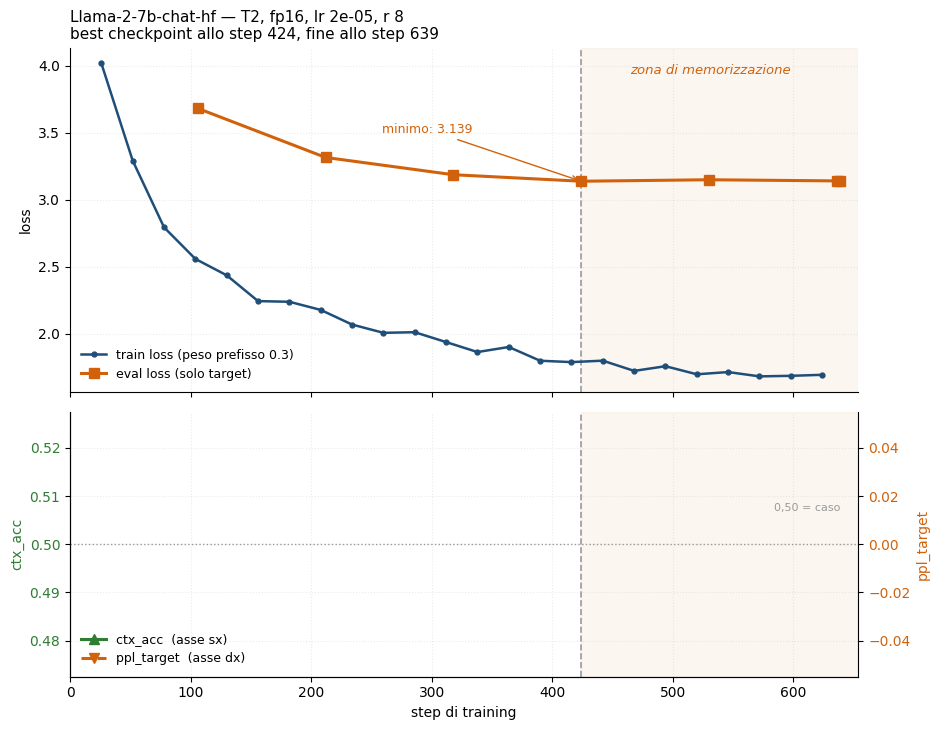

salvato in /kaggle/working/runs/t2_llama_v2/curve.png


In [20]:
# --- 11b. Grafico delle curve ------------------------------------------------
import matplotlib.pyplot as plt

if not per_step:
    print("niente da disegnare: summary.json senza 'log_history'.")
else:
    tr = curve["loss"].dropna()
    ev = curve["eval_loss"].dropna()
    best = int(ev.idxmin()) if len(ev) else None
    fine = int(curve.index.max())

    BLU, ARA, VER, GRI = "#1f4e79", "#d1620b", "#2e7d32", "#9a9a9a"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.4), sharex=True,
                                   gridspec_kw={"height_ratios": [1.3, 1]})
    for ax in (ax1, ax2):
        if best is not None:
            # tutto cio' che sta a destra del minimo di eval_loss e' training
            # speso a memorizzare: la banda lo rende visibile senza doverlo
            # dedurre dai numeri
            ax.axvspan(best, fine + 15, color=ARA, alpha=.055, zorder=0)
            ax.axvline(best, color=GRI, ls="--", lw=1.2, zorder=1)
        ax.grid(alpha=.25, ls=":")
        for s_ in ("top", "right"):
            ax.spines[s_].set_visible(False)

    eti_tr = f"train loss (peso prefisso {s['iperparametri']['peso_prefisso']})"
    ax1.plot(tr.index, tr.values, color=BLU, lw=1.8, marker="o", ms=3.5,
             label=eti_tr)
    ax1.plot(ev.index, ev.values, color=ARA, lw=2.2, marker="s", ms=6.5,
             label="eval loss (solo target)")
    ax1.set_ylabel("loss")
    ax1.legend(frameon=False, loc="lower left", fontsize=9)
    ax1.set_title(f"{s['repo'].split('/')[-1]} — T2, {s.get('precisione','?')}, "
                  f"lr {s['iperparametri']['lr']:g}, r {s['iperparametri']['lora_r']}"
                  + (f"\nbest checkpoint allo step {best}, fine allo step {fine}"
                     if best is not None else ""),
                  fontsize=11, loc="left")
    if best is not None and best < fine:
        ax1.annotate(f"minimo: {ev.min():.3f}", xy=(best, ev.min()),
                     xytext=(max(0, best - 165), ev.min() + .36), fontsize=9,
                     color=ARA, arrowprops=dict(arrowstyle="->", color=ARA, lw=1))
        ax1.text((best + fine) / 2, ax1.get_ylim()[1] * .97,
                 "zona di memorizzazione", ha="center", va="top",
                 fontsize=9.5, color=ARA, style="italic")

    cx = curve["eval_ctx_acc"].dropna()
    pp = curve["eval_ppl_target"].dropna()
    (l_ctx,) = ax2.plot(cx.index, cx.values, color=VER, lw=2.2, marker="^",
                        ms=6.5, label="ctx_acc  (asse sx)")
    ax2.axhline(0.5, color=GRI, lw=1, ls=":")
    ax2.text(fine, 0.507, "0,50 = caso", fontsize=8, color=GRI, ha="right")
    ax2.set_ylabel("ctx_acc", color=VER); ax2.tick_params(axis="y", labelcolor=VER)
    ax2.set_xlabel("step di training"); ax2.set_xlim(0, fine + 15)

    ax3 = ax2.twinx(); ax3.spines["top"].set_visible(False)
    # handle esplicito: get_lines()[0] sarebbe l'axvline, disegnata prima
    (l_ppl,) = ax3.plot(pp.index, pp.values, color=ARA, lw=2.2, ls="--",
                        marker="v", ms=6.5, label="ppl_target  (asse dx)")
    ax3.set_ylabel("ppl_target", color=ARA); ax3.tick_params(axis="y", labelcolor=ARA)
    ax2.legend([l_ctx, l_ppl], [l_ctx.get_label(), l_ppl.get_label()],
               frameon=False, loc="lower left", fontsize=9)

    fig.tight_layout()
    fig.savefig(f"{OUT}/curve.png", dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"salvato in {OUT}/curve.png")


### Come leggere il grafico

Tre forme, in ordine di gravità.

**Le due loss divergono presto.** Se `eval_loss` tocca il minimo entro la prima
epoca e poi risale mentre la train continua a scendere, il modello sta
memorizzando: la banda arancione marca il training speso per niente. Sul run di
Minerva è successo esattamente questo, con il minimo all'epoca 1 su 3 girate.
Con Gemma in fp32 ogni epoca costa quasi un'ora: **guarda questa cella dopo la
prima valutazione utile, non alla fine.**

**`ctx_acc` scende dopo il minimo.** È il segnale peggiore, perché vuol dire
che il modello sta perdendo l'uso del contesto proprio mentre migliora sul
train. Se `ctx_acc` scende verso 0,50 il fine-tuning sta danneggiando l'unica
cosa che T2 dovrebbe insegnare.

**Attenzione allo scarto verticale fra le due curve.** Con `PESO_PREFISSO > 0`
la train loss include il prefisso a peso ridotto e la eval no: un divario
costante di circa un fattore (peso medio dei token) c'è per costruzione e non è
overfitting. Quello che conta è se il divario **si allarga**.


## Passo 9 — valutazione su dev

Su dev, perche' qui si sceglie ancora: strategia di decodifica, eventuale
correzione di lunghezza. Il test si tocca una volta sola, alla fine.

Ogni run scrive due file in `/kaggle/working/eval`: `.metrics.json` con i numeri
e `.preds.jsonl` con una riga per item (contesto, prefisso, riferimento,
generato, generato tagliato). Il secondo e' quello che va letto a mano: su un
task dove il riferimento e' uno fra molti, venti esempi guardati con attenzione
dicono piu' di tre decimali di chrF++.

In [21]:
# --- 12. Fine-tuned su dev, decodifica scelta in configurazione ---------------
!python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} --split dev \
    --adapter {ADAPTER} --stile {STILE} --dtype {DTYPE} --decodifica {DECODIFICA} \
    --distrattori {DISTRATTORI} --out-dir {EVAL} \
    --tag {MODEL}__T2__finetuned-{DECODIFICA}__dev


precisione: fp16
Loading weights: 100%|█| 291/291 [00:04<00:00, 69.75it/s, Materializing param=mo
=== llama__T2__finetuned-contrastiva__dev | 103 item ===
teacher forcing: {
  "ppl_target": 22.368,
  "acc_token": 0.4091,
  "ctx_acc": 0.6311,
  "delta_logp_per_token": 0.182,
  "n_item_ctx": 103
}
scelta fra candidati: {
  "accuratezza@N": 0.2136,
  "mrr": 0.4217,
  "N": 10,
  "fondo_scala": 0.1,
  "n_item": 103
}
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Contrastive Search was moved to a `custom_generate` repo: https://hf.co/transformers-community/contrastive-search. To prevent loss of backward compatibility, add `custom_generate='transformers-community/contrastive-search'` to your `generate` call before v4.62.0.
Passing `generation_config` together wit

In [22]:
# --- 13. Ablation di decodifica ------------------------------------------------
# Stesso adapter, tre decodifiche. Serve a separare cio' che dipende dal
# modello da cio' che dipende da come lo si interroga: se la greedy produce
# cicli e la contrastiva no, il problema non era l'addestramento.
# La metrica di scelta e' identica in tutti e tre (non dipende dalla
# generazione): si salta per non ricalcolarla tre volte.
for dec in ["greedy", "beam"]:
    cmd = (f"python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} "
           f"--split dev --adapter {ADAPTER} --stile {STILE} --dtype {DTYPE} "
           f"--decodifica {dec} --salta-scelta --out-dir {EVAL} "
           f"--tag {MODEL}__T2__finetuned-{dec}__dev")
    !{cmd}


precisione: fp16
Loading weights: 100%|█| 291/291 [00:04<00:00, 68.28it/s, Materializing param=mo
=== llama__T2__finetuned-greedy__dev | 103 item ===
teacher forcing: {
  "ppl_target": 22.368,
  "acc_token": 0.4091,
  "ctx_acc": 0.6311,
  "delta_logp_per_token": 0.182,
  "n_item_ctx": 103
}
generazione:   0%|                                     | 0/7 [00:00<?, ?batch/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
generazione: 100%|█| 7/7 [00:33<00:00,  4.78s/batch, item=103/103, stima=0.6 min
generazione: 103 item in 0.6 minuti

generazione (libera)      : {
  "chrf++": 9.32,
  "chrf++_beta1": 10.4,
  "tasso_ciclo": 0.0291,
  "densita_dial_gen": 0.374,
  "densita_dial_rif": 0.2557,
  "tasso_copia": 0.0485,
  "rapporto_lunghezza": 0.75,
  "vuote": 0
}
generazione (lungh. contr.): {
  "chrf++": 8.75,
  "chrf++_beta1": 10.29,
  "tasso_ciclo": 0.0,
  "densita_dial_gen": 0.3968,
  "densita_dial

## Passo 10 — valutazione finale su test

Una volta sola, con la configurazione scelta su dev. Se torni indietro a cambiare qualcosa dopo aver visto questi numeri, il test non e' piu' un test.

In [23]:
# --- 14. Test ----------------------------------------------------------------
!python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} --split test \
    --adapter {ADAPTER} --stile {STILE} --dtype {DTYPE} --decodifica {DECODIFICA} \
    --distrattori {DISTRATTORI} --out-dir {EVAL} \
    --tag {MODEL}__T2__finetuned__test

!python -u eval_t2.py --model {MODEL} --split-dir {SPLIT} --split test \
    --zero-shot --stile {STILE} --dtype {DTYPE} --decodifica {DECODIFICA} \
    --distrattori {DISTRATTORI} --out-dir {EVAL} \
    --tag {MODEL}__T2__zero-shot__test


precisione: fp16
Loading weights: 100%|█| 291/291 [00:04<00:00, 71.52it/s, Materializing param=mo
=== llama__T2__finetuned__test | 106 item ===
teacher forcing: {
  "ppl_target": 21.047,
  "acc_token": 0.404,
  "ctx_acc": 0.6887,
  "delta_logp_per_token": 0.1108,
  "n_item_ctx": 106
}
scelta fra candidati: {
  "accuratezza@N": 0.2358,
  "mrr": 0.4522,
  "N": 10,
  "fondo_scala": 0.1,
  "n_item": 106
}
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Contrastive Search was moved to a `custom_generate` repo: https://hf.co/transformers-community/contrastive-search. To prevent loss of backward compatibility, add `custom_generate='transformers-community/contrastive-search'` to your `generate` call before v4.62.0.
Passing `generation_config` together with generatio

## Passo 11 — tabella e lettura qualitativa

### Come leggere le colonne

| colonna | cosa dice | come si legge |
|---|---|---|
| `scelta@N` | fra la continuazione vera e N-1 distrattrici, quella scelta e' la giusta? | **la colonna da guardare per prima**: fondo scala esatto in `scelta_fondo` (0,10 con N=10). A differenza del chrF++ ha una forbice larga |
| `mrr` | rango reciproco medio della continuazione vera | 1,0 = sempre prima; 0,29 e' il valore atteso a caso con N=10 |
| `chrf++` | sovrapposizione di caratteri, beta=2 | **gonfiato dalla lunghezza**: beta=2 pesa il richiamo il doppio. Forbice di 2,8 punti fra caso e baseline banale: da solo non decide niente |
| `chrf++_len` | lo stesso, dopo aver tagliato alle parole attese | **e' questa la colonna da confrontare** fra sistemi |
| `chrf++_b1` | beta=1, precisione e richiamo alla pari | il controllo incrociato: se `chrf++` sale e `_b1` scende, e' solo lunghezza |
| `ciclo` | quota di generazioni con un n-gramma ripetuto | sopra 0,15 il problema e' la DECODIFICA, non l'addestramento |
| `ppl_target` | quanto e' probabile *quella* continuazione | piu' basso e' meglio; confronta fine-tuned vs zero-shot |
| `acc_token` | token di target indovinati al primo colpo | il numero piu' diretto per "sa completarla come sta scritta" |
| `ctx_acc` | usa il contesto? | **0,50 = lo ignora**. Sotto 0,55 il modello e' cieco alla conversazione |
| `densita_dial_gen` vs `_rif` | quanto napoletano c'e' | se `gen` << `rif` (~0,28) il modello scrive italiano |
| `tasso_copia` | ricopia il prefisso invece di continuarlo | e' il fallimento degenere del task, e il chrF++ non lo vede |
| `rapporto_lunghezza` | parole generate / parole di riferimento | > 1,3 e il chrF++ crolla per eccesso di lunghezza |

### Due trappole di misura, entrambe gia' viste su questi dati

**Il chrF++ premia chi scrive lungo.** `sacrebleu.corpus_chrf` usa beta=2, cioe'
pesa il richiamo il doppio della precisione. Prendendo il riferimento *esatto* e
allungandolo di 1,8 volte si perdono solo 13 punti con beta=2, ma 28 con beta=1.
Quindi un modello logorroico batte uno preciso. Confronta sempre sulla colonna
`chrf++_len`, non su `chrf++`.

**Il chrF++ non vede i cicli.** Una generazione come `cioe', cioe', cioe', ...`
conserva i caratteri del riferimento e perde pochi punti, ma e' spazzatura. La
colonna `ciclo` la rende visibile.

E il caso da riconoscere: **chrF++ alto e `ctx_acc` a 0,50**. Il modello ha
imparato lo stile del corpus — le stesse cinquanta forme ad alta frequenza — e
le distribuisce a caso. Il chrF++ premia proprio quello.

In [24]:
# --- 15. Tabella comparativa -------------------------------------------------
import glob, json
import pandas as pd

righe = []
for p in sorted(glob.glob(f"{EVAL}/*.metrics.json")):
    m = json.load(open(p))
    tf = m.get("teacher_forcing", {})
    g, gl = m["generazione"], m["generazione_lunghezza_controllata"]
    sc = m.get("scelta", {})
    righe.append({
        "sistema": m["sistema"], "split": m["split"], "n": m["n"],
        "decod": m.get("decodifica", "greedy"),
        "scelta@N": sc.get("accuratezza@N"), "mrr": sc.get("mrr"),
        "scelta_fondo": sc.get("fondo_scala"),
        "chrf++": g["chrf++"], "chrf++_b1": g["chrf++_beta1"],
        "chrf++_len": gl["chrf++"], "chrf++_len_b1": gl["chrf++_beta1"],
        "ciclo": g["tasso_ciclo"],
        "chrf++_golden": m.get("generazione_solo_golden", {}).get("chrf++"),
        "ppl_target": tf.get("ppl_target"), "acc_token": tf.get("acc_token"),
        "ctx_acc": tf.get("ctx_acc"),
        "dial_gen": g["densita_dial_gen"], "dial_rif": g["densita_dial_rif"],
        "copia": g["tasso_copia"], "len_ratio": g["rapporto_lunghezza"],
        "vuote": g["vuote"],
        "base_prefisso": m["baseline"]["ripeti_il_prefisso"],
        "base_pavimento": m["baseline"]["pavimento_target_mescolati"],
    })
tab = pd.DataFrame(righe).sort_values(["split", "sistema", "decod"])
tab.to_csv("/kaggle/working/risultati_t2.csv", index=False)
display(tab)

,sistema,split,n,decod,scelta@N,mrr,scelta_fondo,chrf++,chrf++_b1,chrf++_len,...,ppl_target,acc_token,ctx_acc,dial_gen,dial_rif,copia,len_ratio,vuote,base_prefisso,base_pavimento
0,few-shot-4,dev,103,contrastiva,0.1650,0.3764,0.1,6.91,7.32,6.50,...,277.247,0.2297,0.6505,0.1188,0.2557,0.0000,0.691,3,13.80,8.99
1,fine-tuned,dev,103,beam,NaN,NaN,NaN,9.07,10.34,8.20,...,22.368,0.4091,0.6311,0.3799,0.2557,0.0194,0.628,0,13.80,8.99
2,fine-tuned,dev,103,contrastiva,0.2136,0.4217,0.1,8.83,10.17,8.73,...,22.368,0.4091,0.6311,0.3591,0.2557,0.0000,0.569,0,13.80,8.99
3,fine-tuned,dev,103,greedy,NaN,NaN,NaN,9.32,10.40,8.75,...,22.368,0.4091,0.6311,0.3740,0.2557,0.0485,0.750,0,13.80,8.99
5,zero-shot,dev,103,contrastiva,0.1650,0.3764,0.1,7.87,7.90,7.62,...,277.247,0.2297,0.6505,0.0948,0.2557,0.0000,0.765,6,13.80,8.99
4,fine-tuned,test,106,contrastiva,0.2358,0.4522,0.1,7.86,9.07,7.40,...,21.047,0.4040,0.6887,0.3253,0.2798,0.0000,0.552,1,13.61,11.38
6,zero-shot,test,106,contrastiva,0.1981,0.4280,0.1,7.95,8.13,7.51,...,221.721,0.2208,0.6226,0.1344,0.2798,0.0000,0.732,11,13.61,11.38


In [25]:
# --- 16. Lettura qualitativa -------------------------------------------------
# Venti esempi guardati con attenzione dicono piu' di tre decimali di chrF++.
# Sono ordinati dal chrF++ piu' basso al piu' alto: in cima trovi i fallimenti,
# ed e' li' che si capisce COSA sbaglia (italiano? fuori tema? troppo lungo?
# ricopia il prefisso?).
import json, sacrebleu
import pandas as pd

FILE = f"{EVAL}/{MODEL}__T2__finetuned__test.preds.jsonl"
# per la lettura su dev: f"{EVAL}/{MODEL}__T2__finetuned-{DECODIFICA}__dev.preds.jsonl"
r = [json.loads(l) for l in open(FILE, encoding="utf-8")]
for x in r:
    x["chrf"] = round(sacrebleu.sentence_chrf(x["generato"], [x["riferimento"]],
                                              word_order=2).score, 1)
d = pd.DataFrame(r).sort_values("chrf")
pd.set_option("display.max_colwidth", 70)
print("=== i 10 peggiori ===")
display(d[["prefisso", "riferimento", "generato", "chrf"]].head(10))
print("=== i 10 migliori ===")
display(d[["prefisso", "riferimento", "generato", "chrf"]].tail(10))
d.to_csv("/kaggle/working/predizioni_t2_test.csv", index=False)

=== i 10 peggiori ===


,prefisso,riferimento,generato,chrf
58,ma è,cchiù piccerella,bbuono,0.0
59,nun saccio si è,nuvantanove o duemila,"mh, mh",0.9
0,ovviamente ce stanno 'e cchiù famose,curry house d' 'o munno,", cioè i tipi",1.5
1,e comunque isso s'ostina a mangià chello e no,sulo s'ostina a nun mangià cucine 'e fore,", cioè",2.0
97,quanno stévamo,cu luca,llà pe' fà,2.0
102,p' 'o centro,pecché tenevo malissimo,", pe' fà",2.1
39,ce aggio miso,"'o tappo, guarda",ll'indivis,2.2
32,"quinni isso piglia sta cosa, se,",s' 'a mette tutta 'mmocca,cioè,2.3
8,e stevamo dicenno appunto ca â,fine ghì a mangià fore,"vabbuò, cioè",2.3
22,"pàteme, 'e tutt' 'e ccose, po' 'a primma cosa","ca nota so' st~, sti ccose verde, e fa",m'aggi'a fà,2.4


=== i 10 migliori ===


,prefisso,riferimento,generato,chrf
76,nun era manco brutto e,nun era manco antipatico,"manco bello, è",15.1
91,"e niente, m'ha ditto 'o nomme accussì e","po' fa ""ma i' t'aggio già vista""",po' è rimasta 'n vacanza,15.3
53,"sì sì, ll'ata",vota ll'avimmo viste,vota è,15.4
37,sputà int' 'o,"cibbo, ovvio","vetrino, cioè",15.7
105,"sì, però è addeventato",ancora cchiù faticoso,nu poco 'e faticariello,16.4
11,"spenno 'e cchiù, o pe' dicere, stevamo parlanno","pure d' 'e chef stellate, magari dice","'e patate, 'e patanelle",18.3
100,'o solito cuoso,'e ll'anfibio,nu sacchetto 'e sparaglie,19.8
19,"quinni ce stévano, saje, 'e","sashimi, ehm, 'e roll accussì","spartere, 'e sushi",20.0
4,addò fanno,'e turtellini,nu menù 'e,20.7
90,e lloro 'nfatti,stévano tipo,ce stévano accussì,39.9


## Se la generazione produce cicli o frasi fuori tema

E' successo nella versione precedente, e la diagnosi non era quella che
sembrava. I numeri in teacher forcing dicevano il contrario di quelli in
generazione:

| | zero-shot | fine-tuned |
|---|---|---|
| `ppl_target` | 77,4 | **22,6** |
| `acc_token` | 0,297 | **0,422** |
| `ctx_acc` | 0,631 | **0,702** |
| `chrf++` | 12,0 | 11,1 |
| `tasso_ciclo` | 0,014 | **0,007** |

La perplessita' era crollata di 3,5 volte: il modello **aveva imparato**. E i
cicli veri erano lo 0,7% delle generazioni — quello che si vedeva guardando i
primi cinque item stampati non era il campione, era il campione dei primi
cinque. Il problema reale era un altro: le continuazioni erano *fuori tema*, e
contenevano frammenti memorizzati dal train (`'a nuvantanove`, che nel train
compare quattro volte, su un item di dev che parla di cioccolato).

Da qui la sequenza di controlli, in quest'ordine.

**1. Guarda `scelta@N` prima del chrF++.** Se sta al fondo scala (0,10 con
N=10) il modello non discrimina, e nessuna decodifica lo salvera'. Se e'
nettamente sopra ma il chrF++ resta piatto, il modello ha imparato e il chrF++
non e' in grado di dirlo: e' il caso normale su questo task.

**2. Guarda `ppl_target` e `acc_token`.** Se scendono/salgono rispetto allo
zero-shot, l'addestramento funziona. Un chrF++ che peggiora mentre questi
migliorano non e' una contraddizione: sono due domande diverse.

**3. Guarda `tasso_ciclo`.** Sopra 0,15 e' un problema di decodifica: prova
`--decodifica beam` o alza `--no-repeat`. Sotto 0,05 i cicli non sono il
problema, per quanto siano quelli che saltano all'occhio leggendo.

**4. Guarda i token OOV nell'output del Passo 2b.** Sopra il 20% stai
valutando su argomenti che nel train non esistono, e nessun iperparametro
compensa una cosa del genere.

**5. Solo alla fine, guarda `rapporto_lunghezza`.** Sotto 0,7 il modello
chiude troppo presto: alza `--frazione-min`. Sopra 1,3 il chrF++ libero e'
gonfiato e va letta la riga a lunghezza controllata.


In [26]:
# --- 17. Backup --------------------------------------------------------------
REPO_HUB = "TUO_UTENTE/minerva-nap-t2"     # <-- cambia
PRIVATO  = True

import glob, os, shutil
from huggingface_hub import HfApi, create_repo

stage = "/kaggle/working/backup_t2"
shutil.rmtree(stage, ignore_errors=True)
shutil.copytree(f"{OUT}/adapter_final", f"{stage}/adapter_final")
shutil.copy(f"{OUT}/summary.json", f"{stage}/summary.json")
for nome in ("curve.csv", "curve.png"):
    if os.path.exists(f"{OUT}/{nome}"):
        shutil.copy(f"{OUT}/{nome}", f"{stage}/{nome}")
os.makedirs(f"{stage}/eval", exist_ok=True)
for p in glob.glob(f"{EVAL}/*.json") + glob.glob(f"{EVAL}/*.jsonl"):
    shutil.copy(p, f"{stage}/eval/")
for p in ("/kaggle/working/audit_t2.json", "/kaggle/working/risultati_t2.csv"):
    if os.path.exists(p):
        shutil.copy(p, stage)

create_repo(REPO_HUB, private=PRIVATO, exist_ok=True,
            token=os.environ["HF_TOKEN"])
HfApi().upload_folder(folder_path=stage, repo_id=REPO_HUB,
                      token=os.environ["HF_TOKEN"],
                      commit_message="T2 completamento turno — adapter + metriche")
print("caricato su", REPO_HUB)

HfHubHTTPError: (Request ID: Root=1-6a957173-67a95b1f28e654070a279e18;7f77eaba-622d-4e75-bd50-bc0bd30a1aa2)

403 Forbidden: You don't have the rights to create a model under the namespace "TUO_UTENTE".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

In [ ]:
# --- 18. Ripartenza in una sessione nuova ------------------------------------
# Da eseguire DOPO i Passi 1-3 e 5, al posto del training, se l'adapter e' gia'
# su Hub. Poi si prosegue dal Passo 9.
#
# from huggingface_hub import snapshot_download
# ADAPTER = snapshot_download(REPO_HUB, allow_patterns=["adapter_final/*"],
#                             token=os.environ["HF_TOKEN"]) + "/adapter_final"
# print(ADAPTER)
print("cella di ripristino: decommenta quando serve")

## Se i risultati non convincono — cosa provare, in ordine

Le cinque modifiche di questa versione sono indipendenti: si spengono una alla
volta e si rifa' il run. E' cosi' che si misura quanto vale ciascuna, invece di
cambiare cinque cose insieme e non sapere quale ha funzionato.

**1. `SCHEMA = "originale"` (zero GPU in piu').** Rifa' tutto sui file
originali. La differenza fra i due run e' la misura diretta dell'effetto della
deriva tematica, e ci si aspetta che sia la piu' grande delle cinque.

**2. `PESO_PREFISSO = 0.0` (un run).** Torna alla loss sul solo target. Se il
risultato non cambia, la supervisione extra non serviva e la spiegazione e'
che il collo di bottiglia sono i dati, non il segnale per esempio.

**3. `DECODIFICA` (nessun training, solo valutazione).** La cella di ablation
gira gia' greedy e beam sullo stesso adapter. Se contrastiva e greedy danno lo
stesso `scelta@N` ma chrF++ molto diversi, stai misurando la decodifica e non
il modello.

**4. `--solo-golden` nel training (un run).** Toglie dal train i 246 target
sintetici. Se il risultato migliora, il modello stava imitando gemma4 invece
del parlato reale.

**5. `--stile chat` (un run, ~30 minuti).** Quantifica quanto vale il prefill.
Se la differenza e' grande e' un risultato da riportare; se e' piccola, il
prefill resta il default perche' e' comunque piu' pulito da valutare.

E una cosa da non provare per prima: alzare `EPOCHS` o `LR`. Nella versione
precedente il best checkpoint cadeva a fine prima epoca — il modello
memorizzava prima di generalizzare, e piu' addestramento peggiorava le cose.

### Se dopo tutto questo il fine-tuning resta sotto il few-shot

E' un risultato, non un fallimento, e va scritto come tale: **su due
conversazioni, con circa 3.400 istanze derivate da 1.100 turni reali, l'SFT su
T2 migliora la modellazione del target (perplessita', accuratezza token,
accuratezza di scelta) ma non la qualita' della generazione libera, perche' il
corpus e' parlato spontaneo frammentario e la continuazione di un turno non e'
determinata dal suo inizio.** Le metriche in teacher forcing e l'ablation di
decodifica servono esattamente a poter fare questa affermazione con dei numeri
dietro, invece di dire "non ha funzionato".
